## Imports and configs

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

from utils import * 

plt.rcParams["figure.dpi"] = 120

## Load experiment runs

In [2]:
def load_experiment(exp_dir):
    exp_dir = Path(exp_dir)
    beta_dirs = sorted(exp_dir.glob("beta_*"))
    data = {}
    for d in beta_dirs:
        beta = float(d.name.split("_")[1])
        file = d / "partial_results.pt"

        if not file.exists():
            print(f"Skipping {d} (no results)")
            continue

        obj = torch.load(file, map_location="cpu")
        data[beta] = obj
        
    sorted_items = sorted(data.items())
    if sorted_items:
        sorted_items = sorted_items[:-1] # not the last value beta = 5
    print(f"Loaded {len(sorted_items)} beta values (dropped the largest/last beta)")
    
    return dict(sorted_items)

In [3]:
exp_dir = "results_bim_theta_beta/bim_theta_beta_sweep_20260629_145859/"
data = load_experiment(exp_dir)

betas = list(data.keys())

Loaded 8 beta values (dropped the largest/last beta)


In [4]:
for key, value in data.items():
    print(f"Top-level key: {key}")
    print("Subkeys:", list(value.keys()))
    print()

Top-level key: 0.1
Subkeys: ['theta_traj_mgd', 'theta_final_mgd', 'theta_traj_reg', 'theta_final_reg', 'runs_done', 'target_theta', 'complexity', 'config']

Top-level key: 0.3
Subkeys: ['theta_traj_mgd', 'theta_final_mgd', 'theta_traj_reg', 'theta_final_reg', 'runs_done', 'target_theta', 'complexity', 'config']

Top-level key: 0.5
Subkeys: ['theta_traj_mgd', 'theta_final_mgd', 'theta_traj_reg', 'theta_final_reg', 'runs_done', 'target_theta', 'complexity', 'config']

Top-level key: 0.7
Subkeys: ['theta_traj_mgd', 'theta_final_mgd', 'theta_traj_reg', 'theta_final_reg', 'runs_done', 'target_theta', 'complexity', 'config']

Top-level key: 0.9
Subkeys: ['theta_traj_mgd', 'theta_final_mgd', 'theta_traj_reg', 'theta_final_reg', 'runs_done', 'target_theta', 'complexity', 'config']

Top-level key: 1.1
Subkeys: ['theta_traj_mgd', 'theta_final_mgd', 'theta_traj_reg', 'theta_final_reg', 'runs_done', 'target_theta', 'complexity', 'config']

Top-level key: 1.3
Subkeys: ['theta_traj_mgd', 'theta_fina

In [5]:
def extract_metric(data, key, is_scalar=False):
    """Safely extracts metrics across all beta sweeps handling both tensors and scalars."""
    out = []
    for beta in data.keys():
        val = data[beta][key]
        if torch.is_tensor(val):
            val = val.cpu().numpy()
        out.append(val)
    return np.array(out) if is_scalar else np.stack(out)

In [6]:
betas_np = np.array(list(data.keys()))
labels = ["x", "x²", "x³", "x⁴"]

In [7]:
# --- Extract Parameter Metrics (Shape: n_beta, 4) ---
var_mgd = extract_metric(data, "var_final_mgd")
var_reg = extract_metric(data, "var_final_reg")
cr_theta = extract_metric(data, "cr_bound_theta")  # Contains the diagonal elements

# --- Extract Energy Metrics (Shape: n_beta,) ---
var_energy_mgd = extract_metric(data, "var_energy_mgd", is_scalar=True)
var_energy_reg = extract_metric(data, "var_energy_reg", is_scalar=True)
cr_energy      = extract_metric(data, "cr_bound_energy", is_scalar=True)

KeyError: 'var_final_mgd'

## Variance vs beta

### Plot per component 

In [8]:
# Scaling law and variance comparison with CR Bound
for i in range(4):
    #plt.figure(figsize=(7,5))
    #plt.plot(var_mgd[:,i] / var_reg[:,i], label="mgd/reg") 
    #plt.plot(var_mgd[:,i] / cr_theta[:,i], label="mgd/cr")
    #plt.plot(var_reg[:,i] / cr_theta[:,i], label="reg/cr")
    #plt.legend() 
    #plt.show() 
    plt.figure(figsize=(7, 5))
    plt.plot(betas_np, var_mgd[:, i], 'o-', label="MGD Variance", color='royalblue')
    plt.plot(betas_np, var_reg[:, i], 'o-', label="REG Variance", color='darkorange')
    plt.plot(betas_np, cr_theta[:, i], '--', marker="*", label="Cramér-Rao Bound", color='crimson', linewidth=2)
    plt.yscale('log')
    plt.xlabel(r"$\beta$ (log scale)")
    plt.ylabel(f"Var(theta_{labels[i]})")
    plt.title(f"Parameter Variance Scaling & CR Bound ({labels[i]})")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

NameError: name 'var_mgd' is not defined

<Figure size 840x600 with 0 Axes>

## Energy variance vs Cramer-Rao bound

## Maybe this CR bound which is flat is not actually correct. We decided not to look at the CR bound anymore but at the kl divergence

In [9]:
plt.figure(figsize=(8, 5.5))
plt.plot(betas_np, var_energy_mgd, 'o-', label="MGD Energy Var", color='royalblue')
plt.plot(betas_np, var_energy_reg, 'o-', label="REG Energy Var", color='darkorange')
plt.plot(betas_np, cr_energy, 'o--', label="Energy Cramér-Rao Bound", color='crimson', linewidth=2)
plt.plot(betas_np, cr_energy_correct, 'o--', label="Energy Cramér-Rao Bound", color='magenta', linewidth=2)
plt.yscale('log')
plt.xlabel(r"$\beta$ (log scale)")
plt.ylabel("Variance of Energy")
plt.title("Global Energy Variance Scaling vs. Cramér-Rao Bound")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Print efficiency ratio relative to the lower bound
for idx, beta in enumerate(betas_np):
    print(f"Beta = {beta:.3f} | MGD-to-CR: {var_energy_mgd[idx]/cr_energy[idx]:.2f}x | REG-to-CR: {var_energy_reg[idx]/cr_energy[idx]:.2f}x")

NameError: name 'var_energy_mgd' is not defined

<Figure size 960x660 with 0 Axes>

## Relative energy variance

### MGD / reg ratio

In [10]:
ratio = var_mgd / var_reg

for i in range(4):
    plt.figure()
    plt.plot(betas_np, ratio[:, i], marker='o')
    plt.axhline(1.0, linestyle='--')
    plt.xlabel("beta")
    plt.ylabel("Var(MGD) / Var(REG)")
    plt.title(f"Variance reduction factor ({labels[i]})")
    plt.grid()
    plt.show()

NameError: name 'var_mgd' is not defined

In [11]:
target = np.array([
    [beta/2, 5*beta, 0, -beta] for beta in betas_np
])

(8, 4)


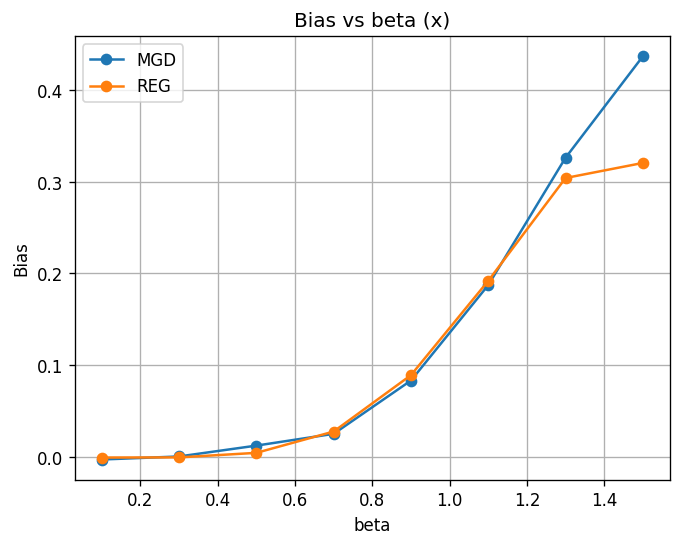

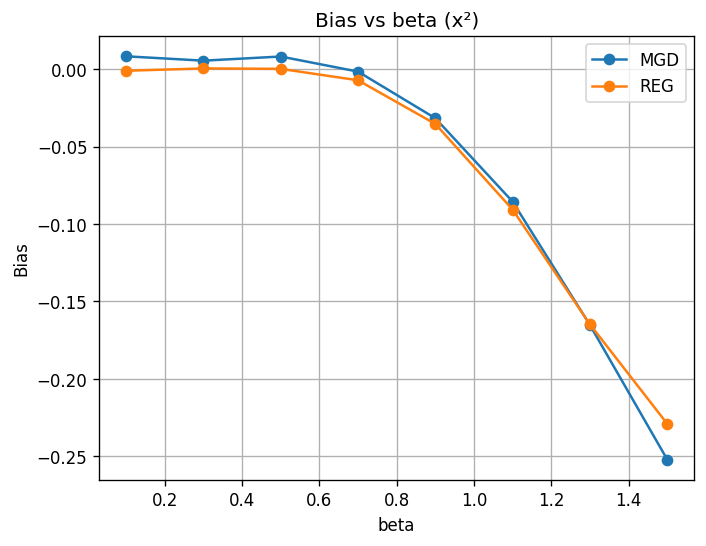

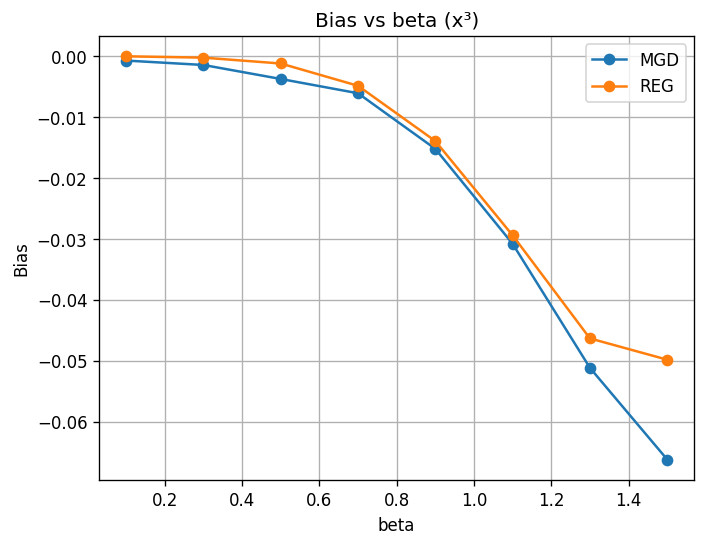

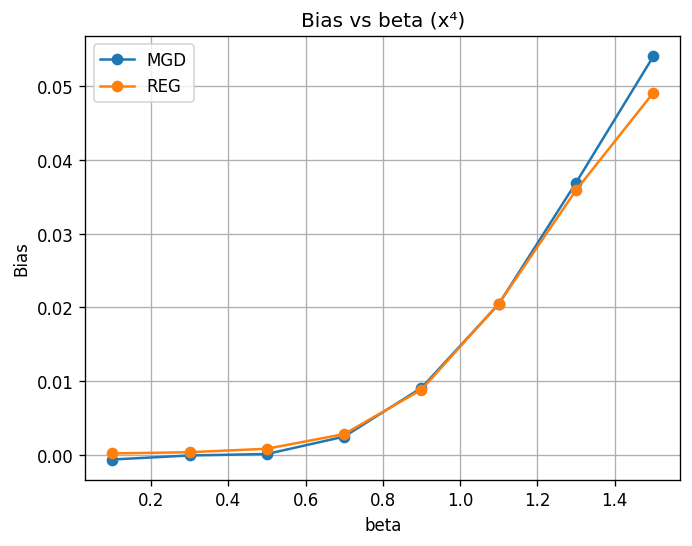

In [12]:
scale_factor = np.array([1, 2, 3, 4])

def extract_mean(data, key):
    # Scale each extracted numpy mean directly inside or right after
    return np.stack([data[b][key].mean(0).numpy() for b in data])

mean_mgd = extract_mean(data, "theta_final_mgd") / scale_factor
mean_reg = extract_mean(data, "theta_final_reg") / scale_factor
print(mean_mgd.shape) # (n_beta, 4)


# Bias plot
for i in range(4):
    plt.figure()
    plt.plot(betas_np, mean_mgd[:, i] - target[:,i], marker='o', label="MGD")
    plt.plot(betas_np, mean_reg[:, i] - target[:,i], marker='o', label="REG")
    plt.xlabel("beta")
    plt.ylabel("Bias")
    plt.title(f"Bias vs beta ({labels[i]})")
    plt.legend()
    plt.grid()
    plt.show()



## 5. Trajectory analysis

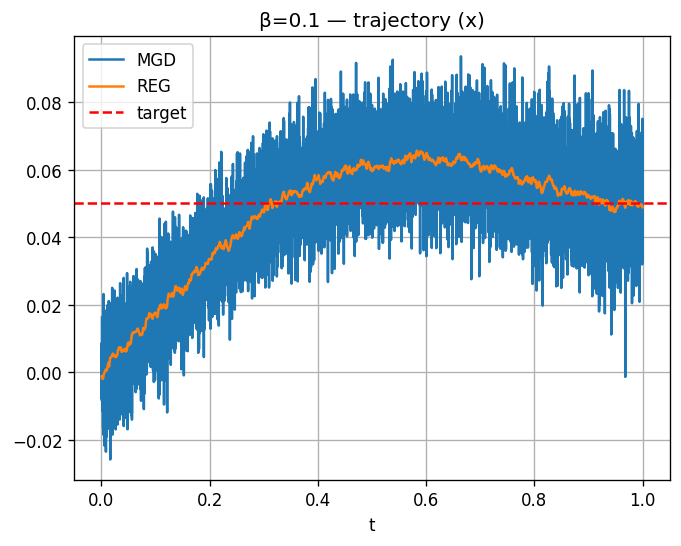

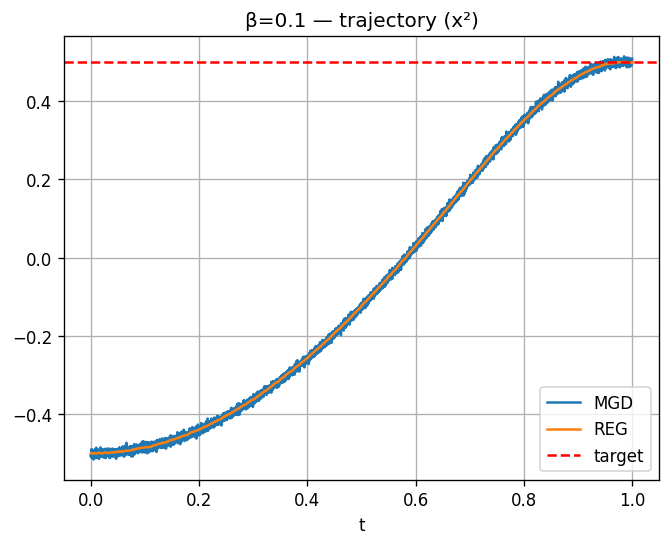

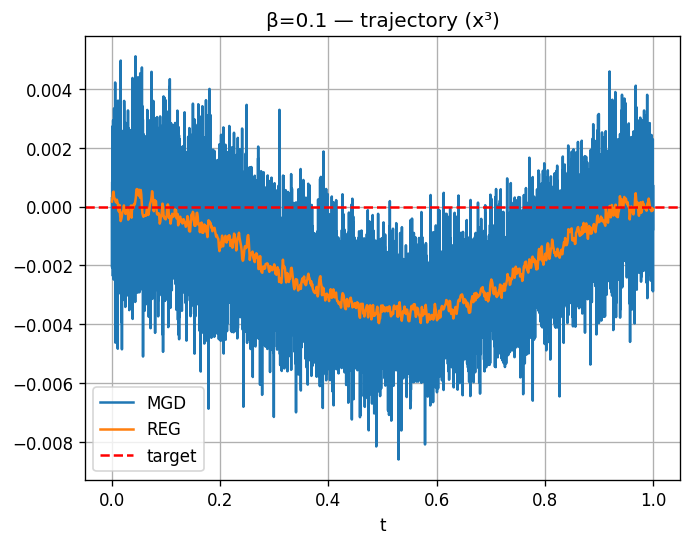

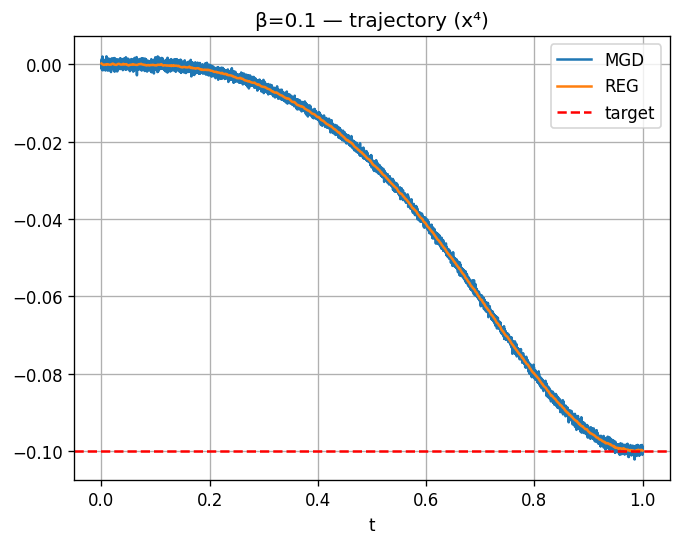

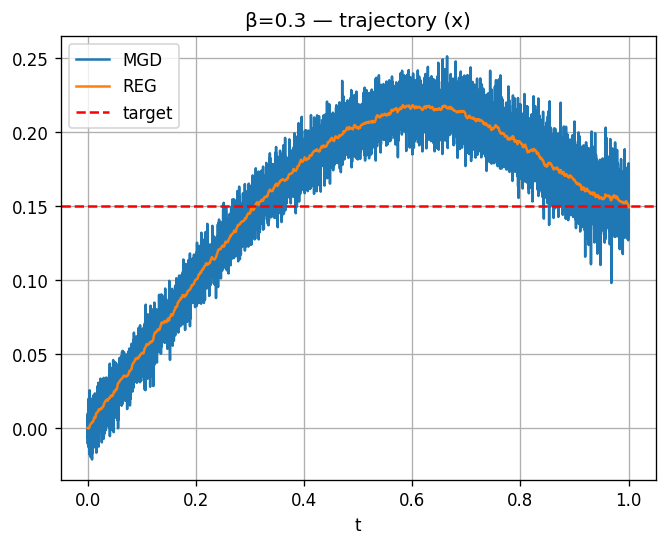

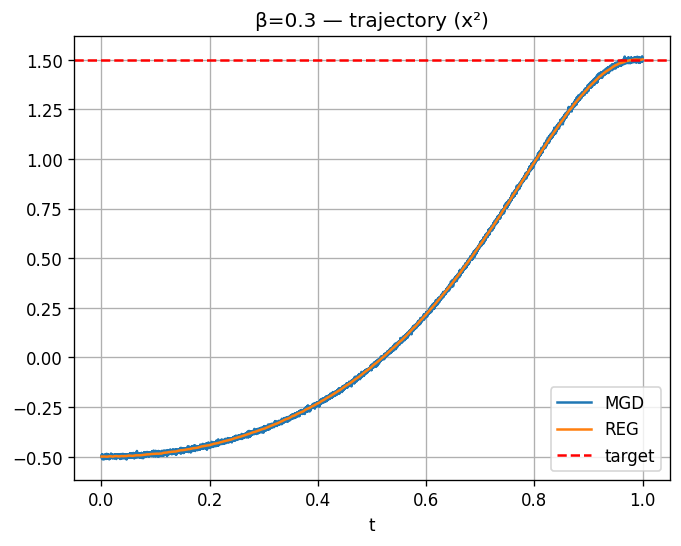

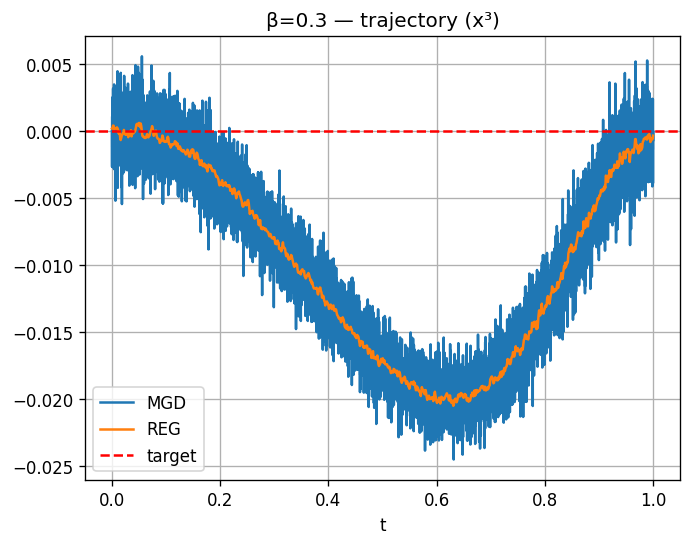

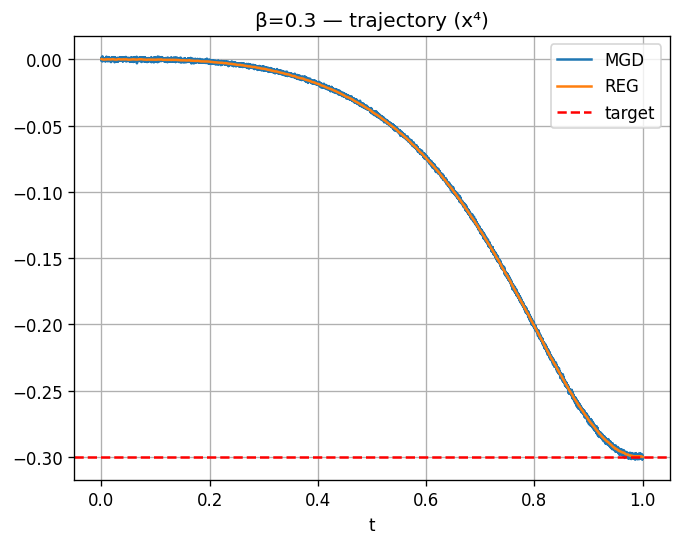

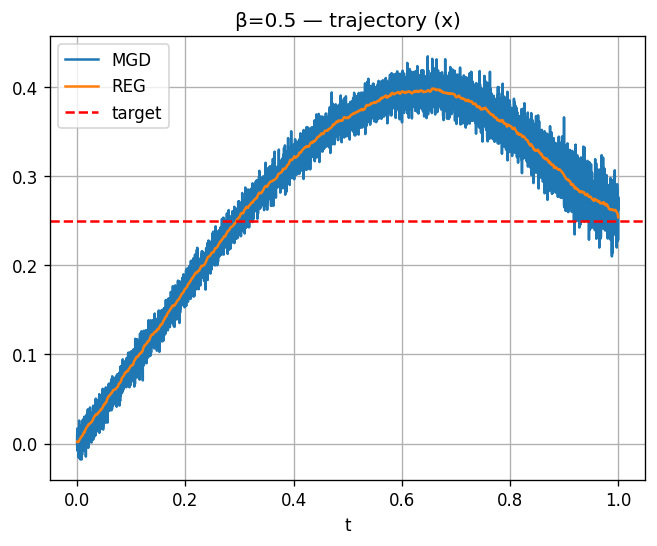

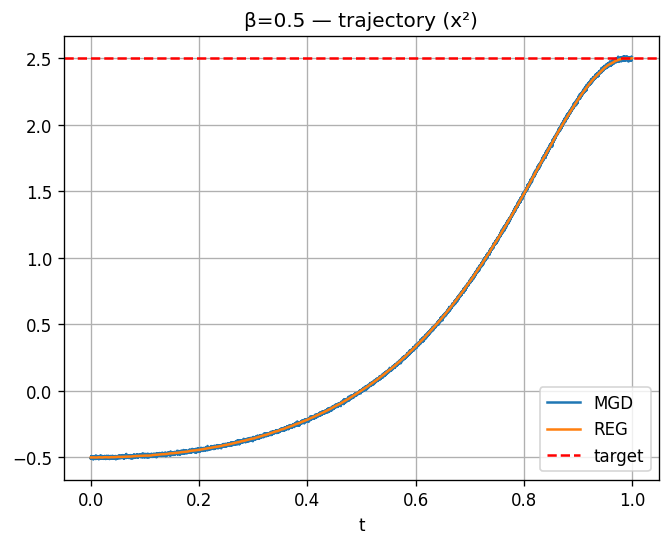

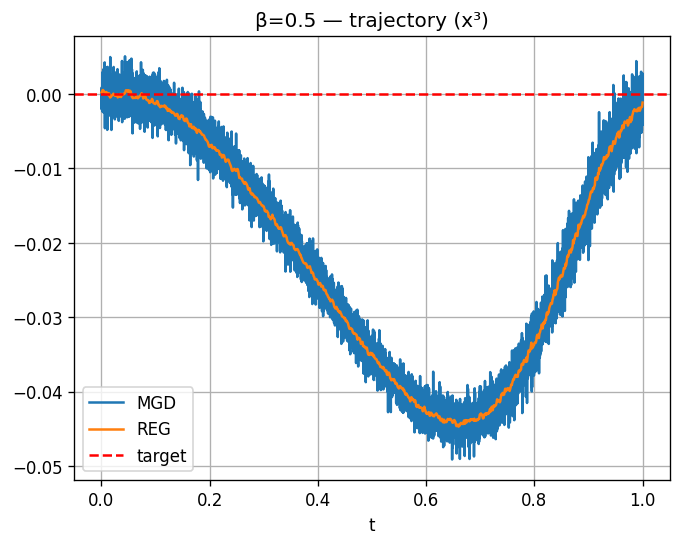

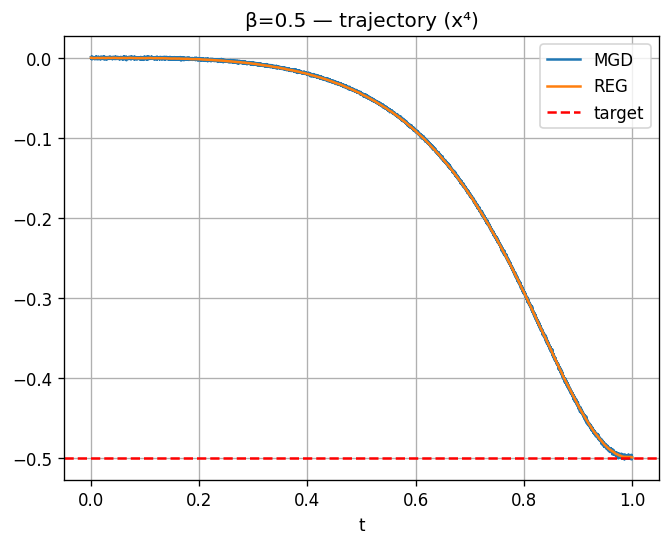

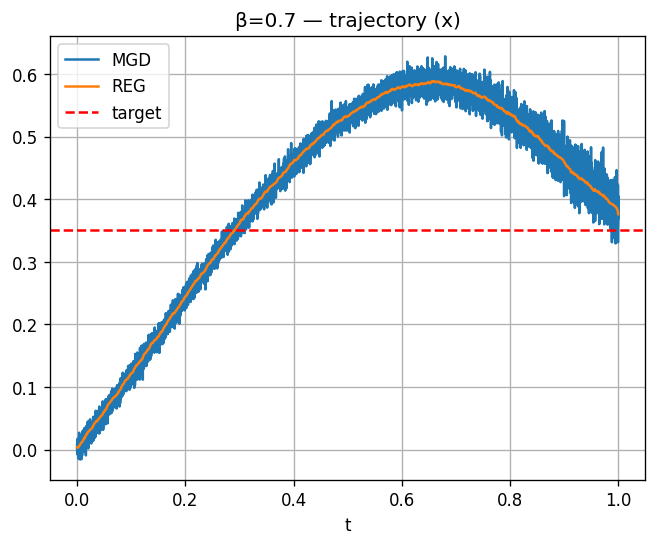

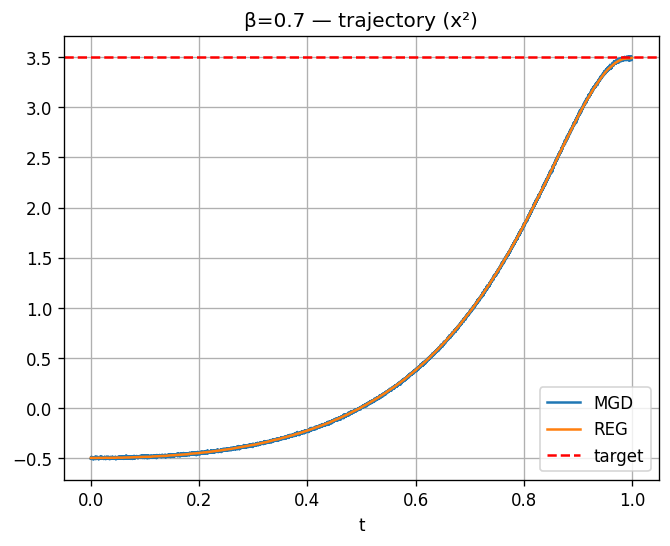

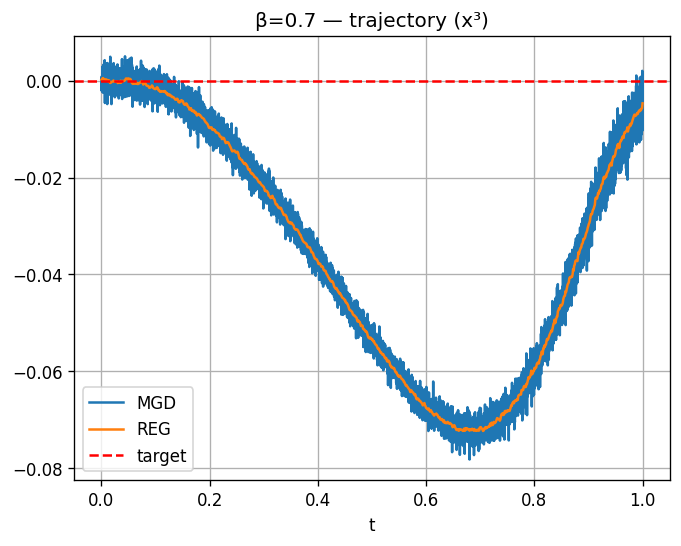

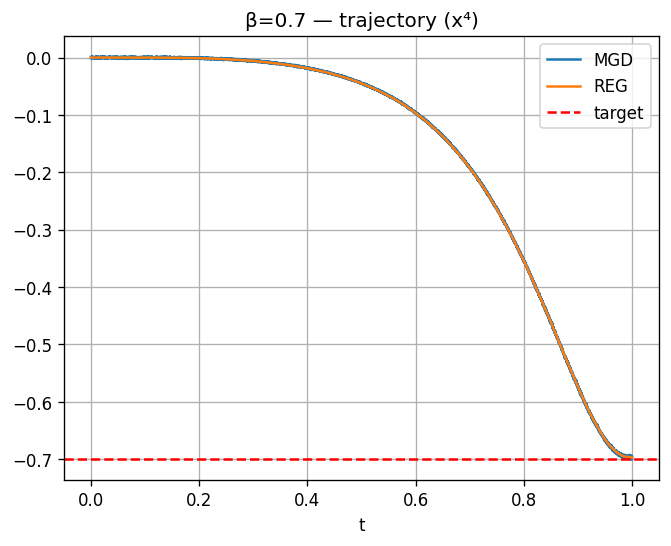

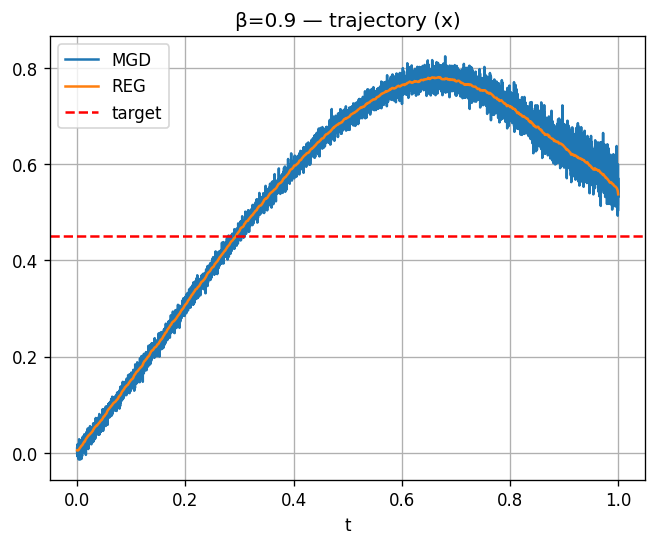

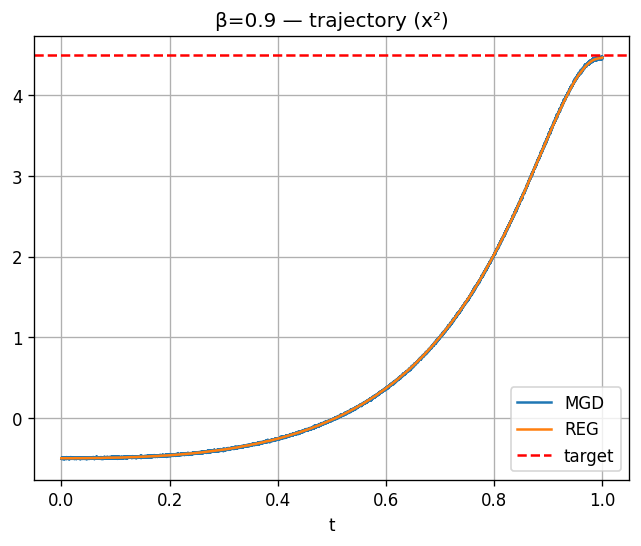

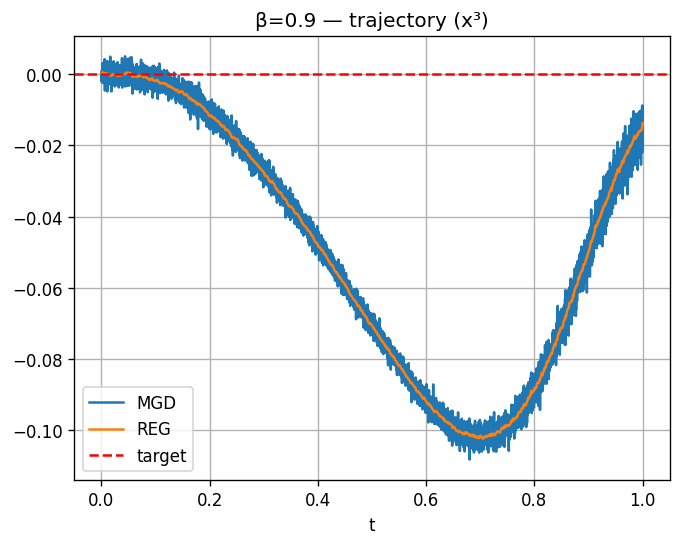

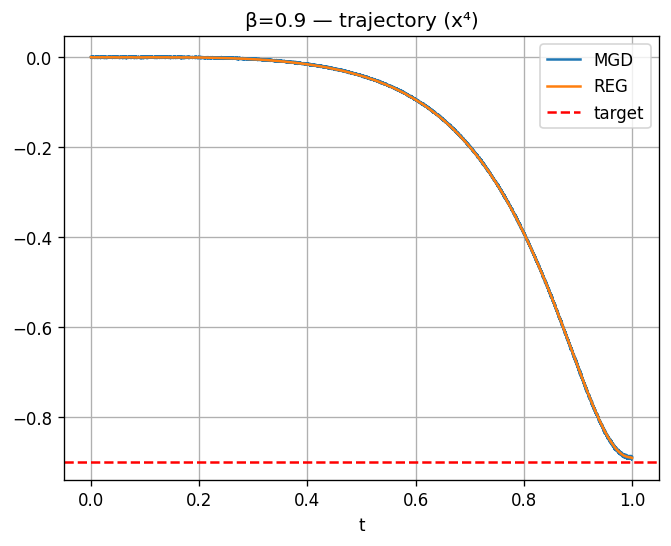

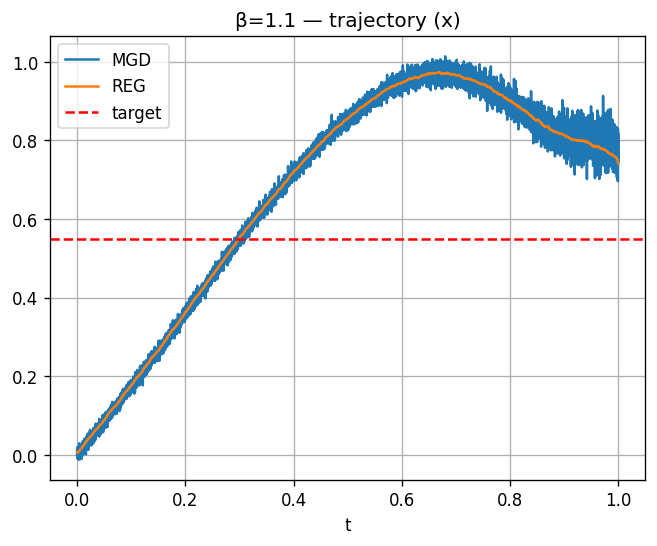

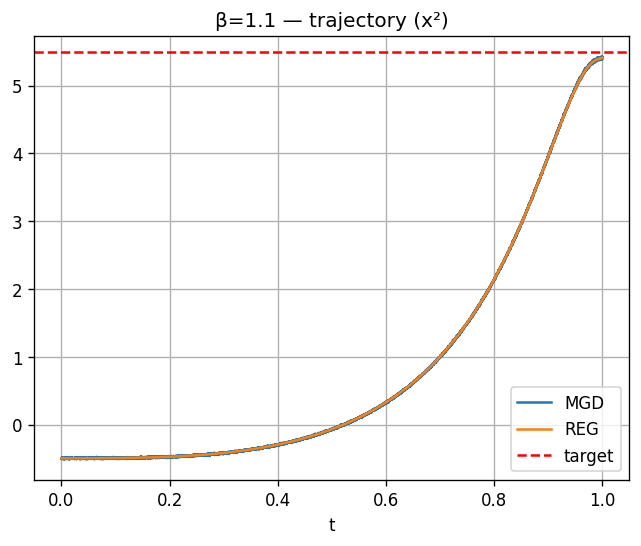

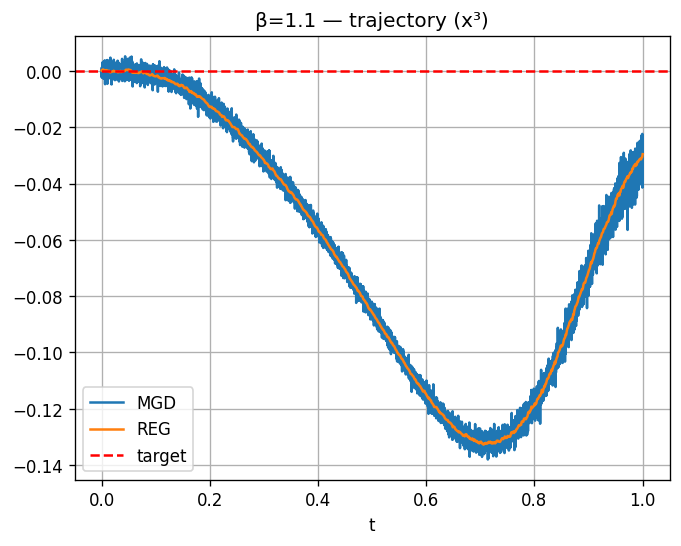

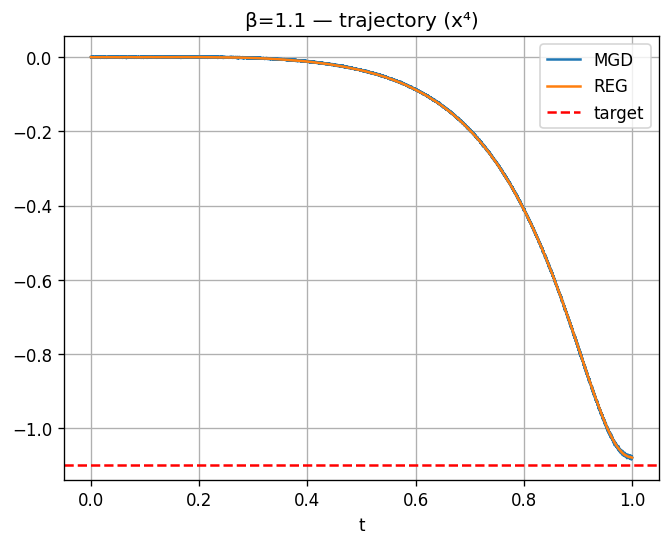

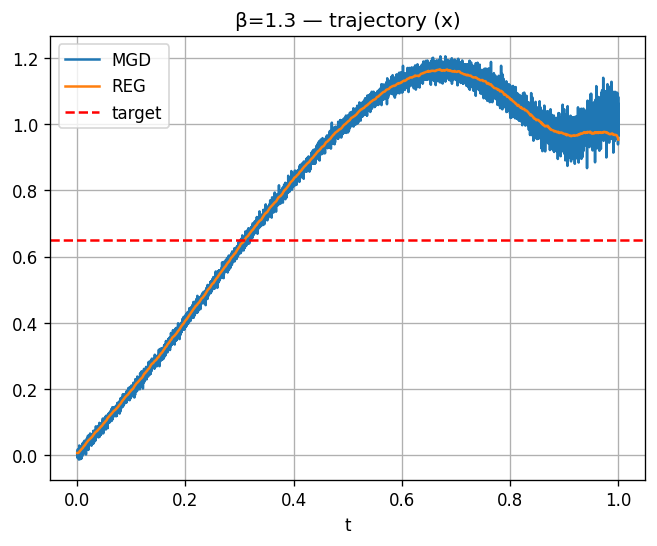

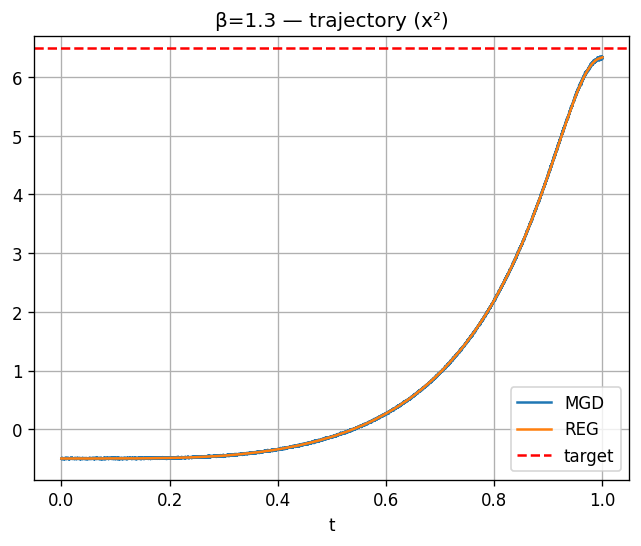

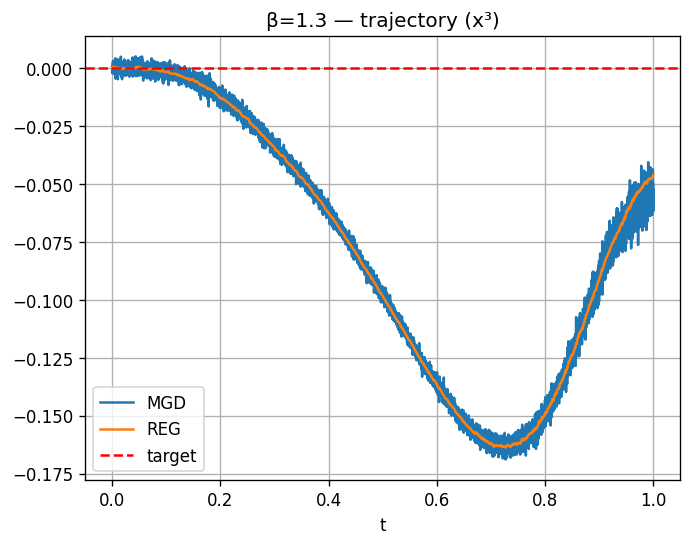

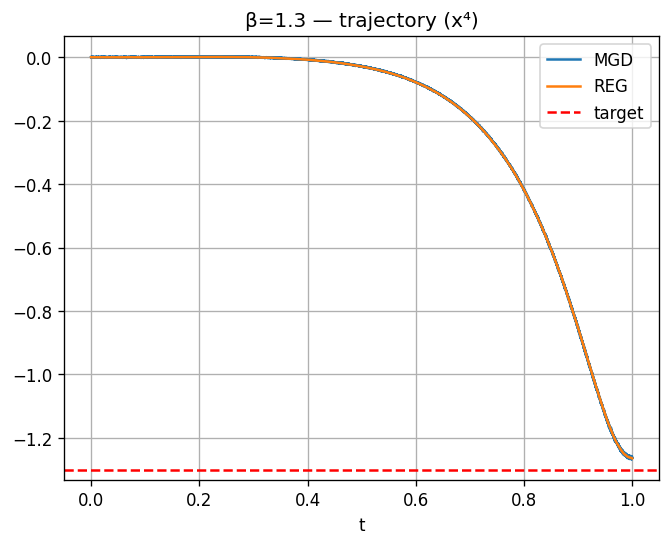

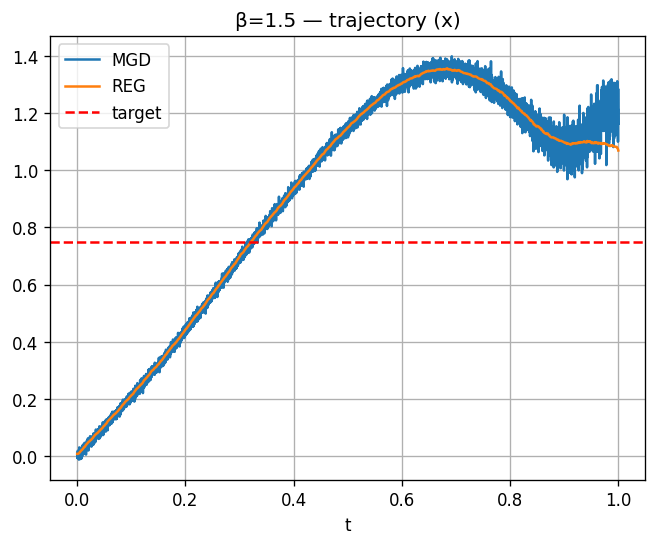

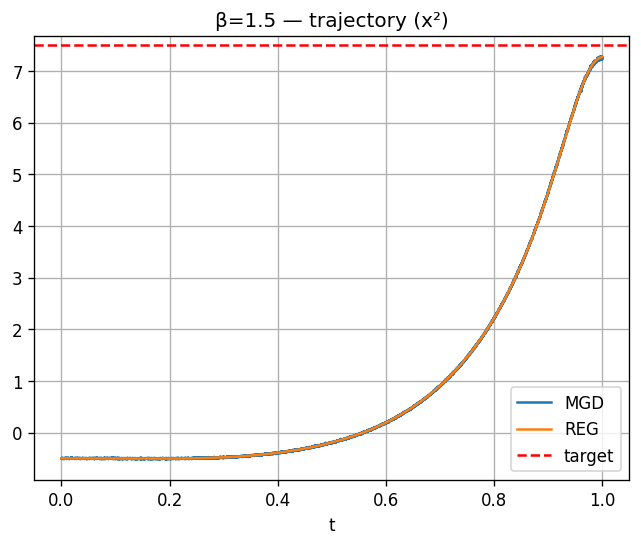

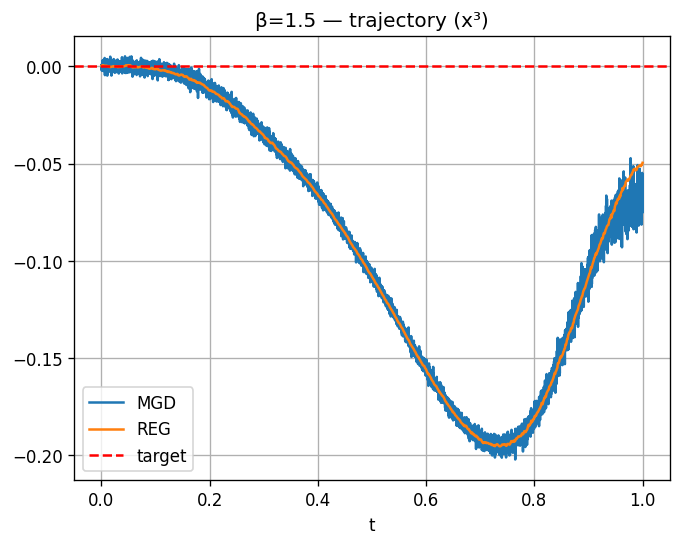

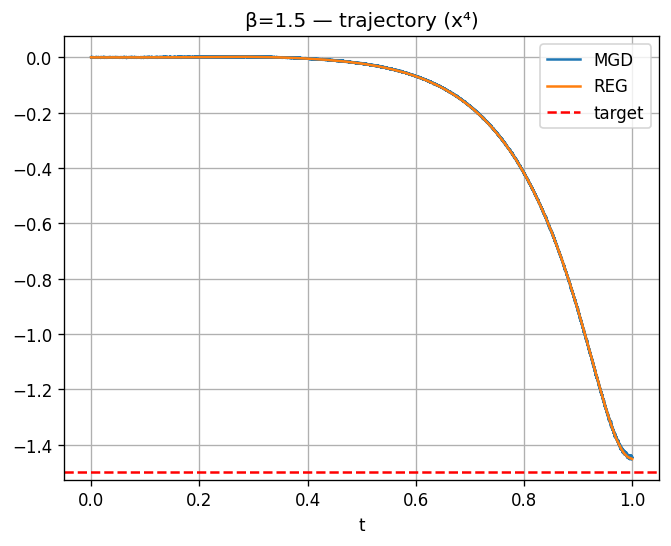

In [36]:
##Pick a few β values:
selected_betas = betas

#Mean trajectory over runs

def mean_traj(obj, key):

    return obj[key].mean(0)  # average over K# Use enumerate to keep track of the current beta's index row

for idx, beta in enumerate(betas_np):
    d = data[beta]

    traj_mgd = mean_traj(d, "theta_traj_mgd")/torch.Tensor([1,2,3,4])  # (nt+1, 4)
    traj_reg = mean_traj(d, "theta_traj_reg")/torch.Tensor([1,2,3,4])  # (n, 4)

    t_mgd = np.linspace(0, 1, traj_mgd.shape[0])
    t_reg = np.linspace(0, 1, traj_reg.shape[0])

    for i in range(4):
        plt.figure()
        plt.plot(t_mgd, traj_mgd[:, i], label="MGD")
        plt.plot(t_reg, traj_reg[:, i], label="REG")
        
        # FIXED: target[idx, i] extracts the scalar target for the CURRENT beta
        plt.axhline(target[idx, i], linestyle='--', color='red', label="target")
        
        plt.title(f"β={beta} — trajectory ({labels[i]})")
        plt.xlabel("t")
        plt.legend()
        plt.grid()
        plt.show()

# 6. Variance along trajectory

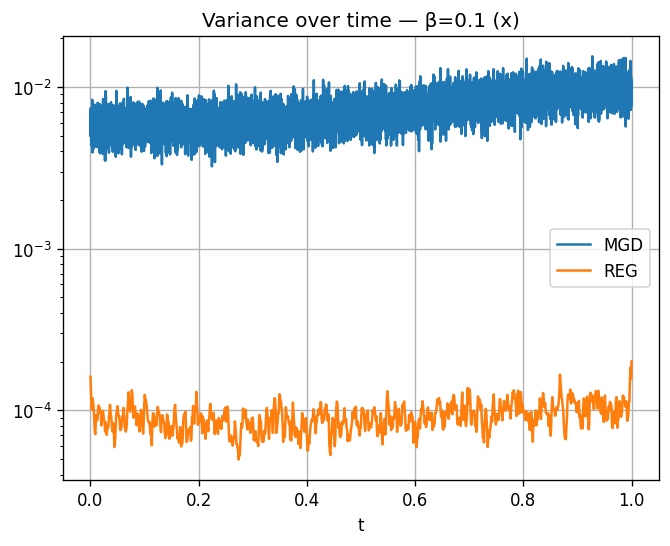

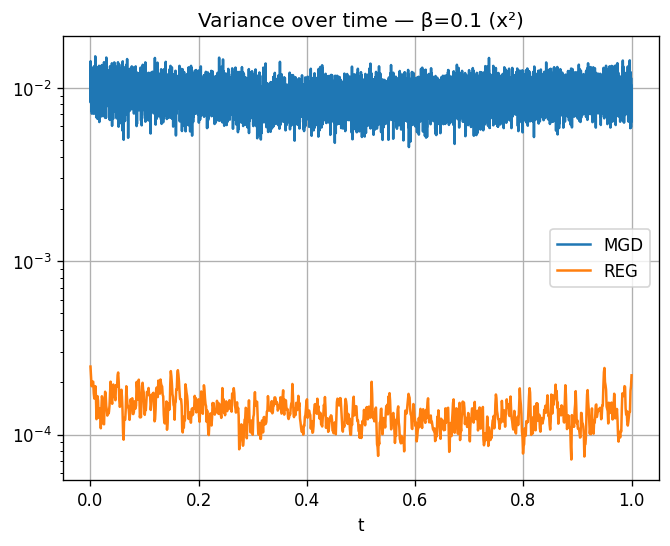

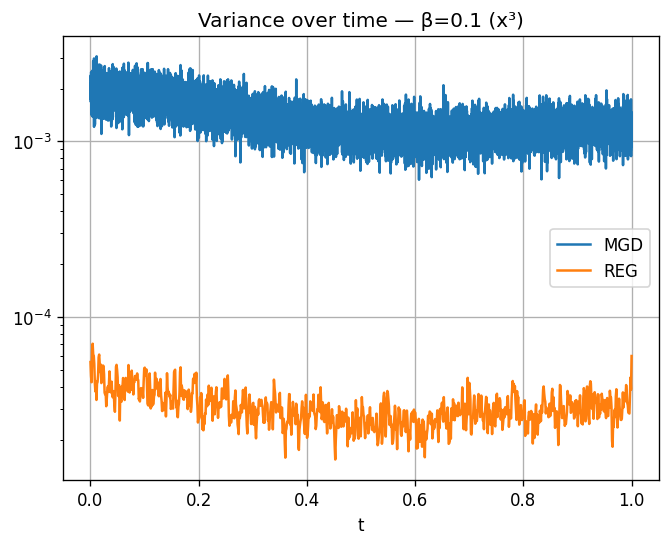

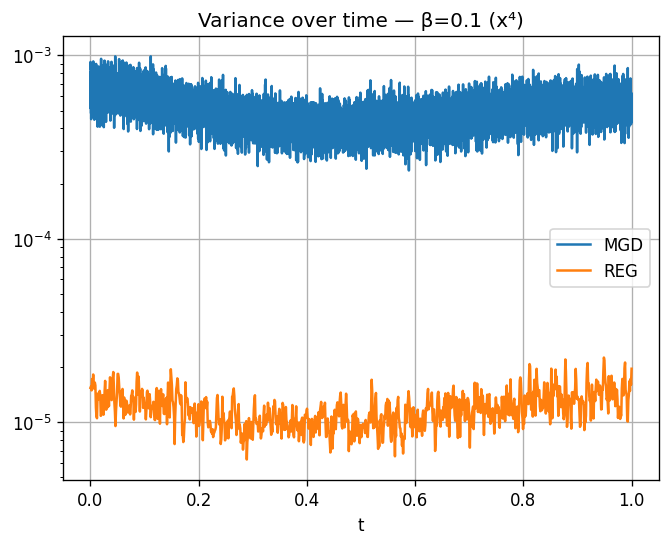

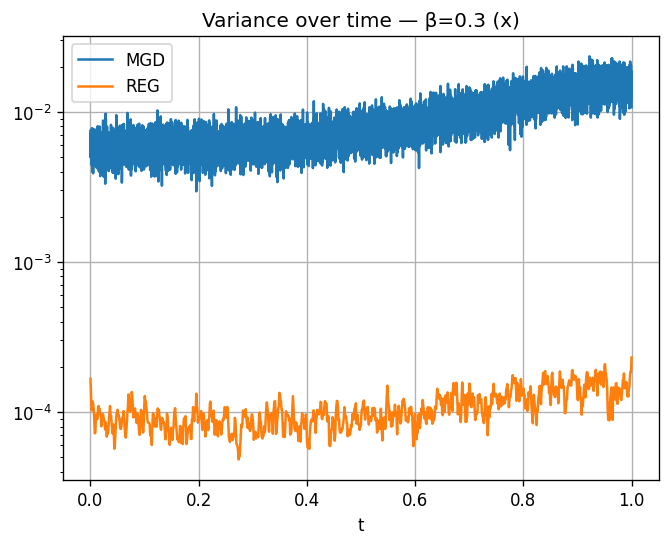

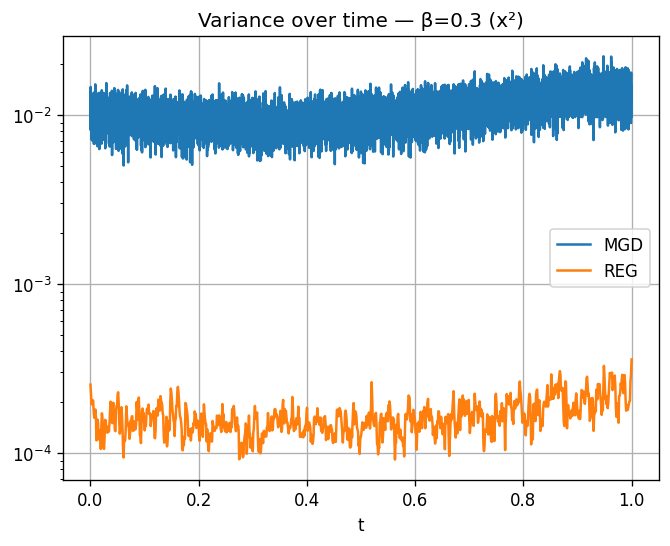

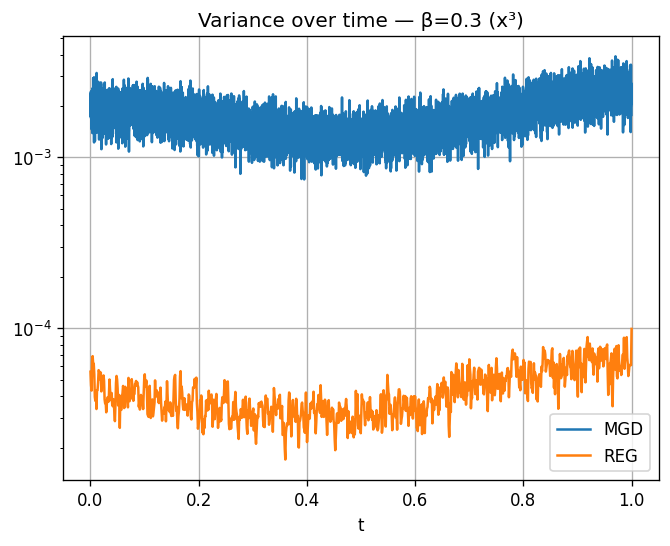

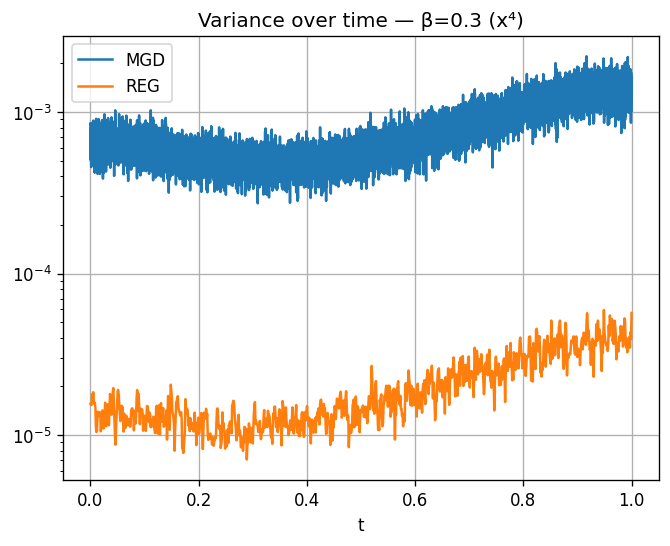

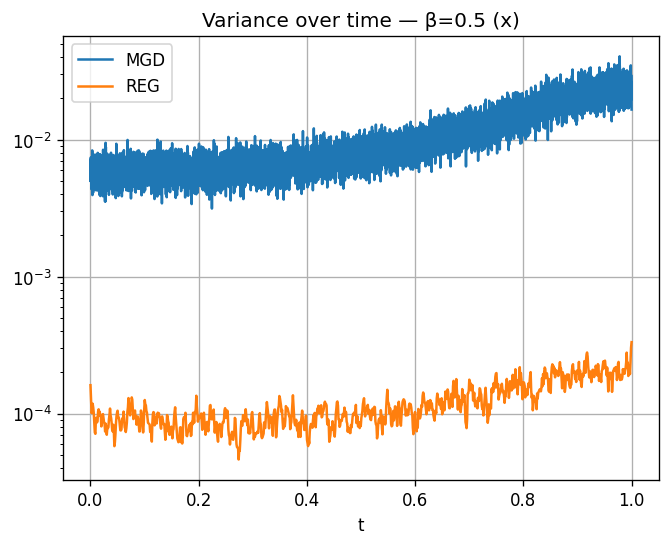

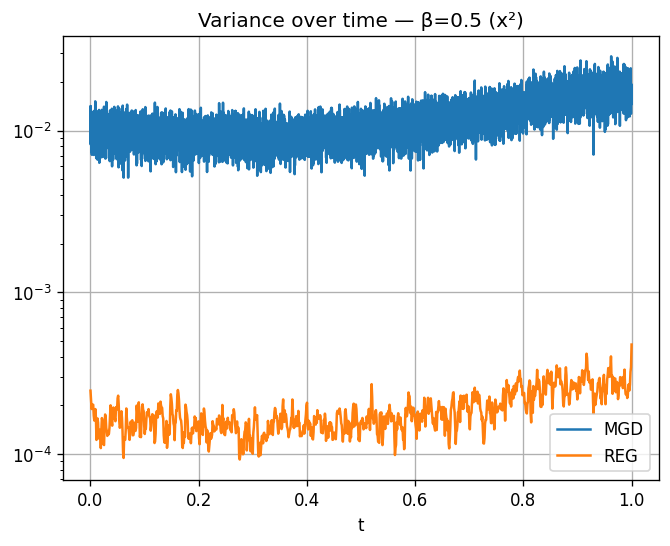

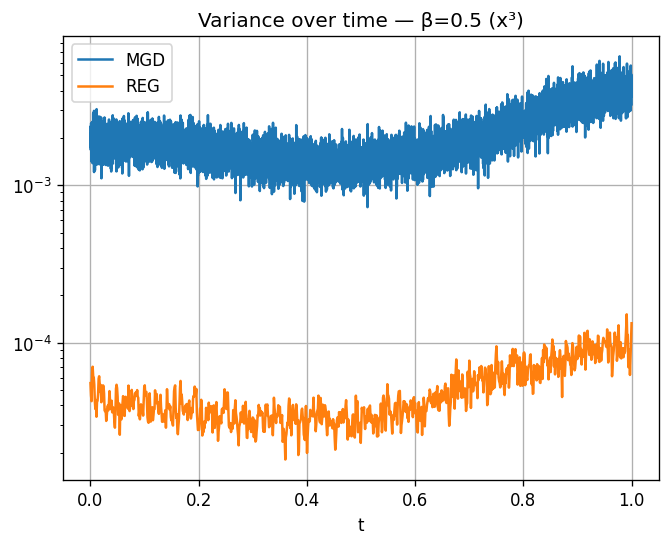

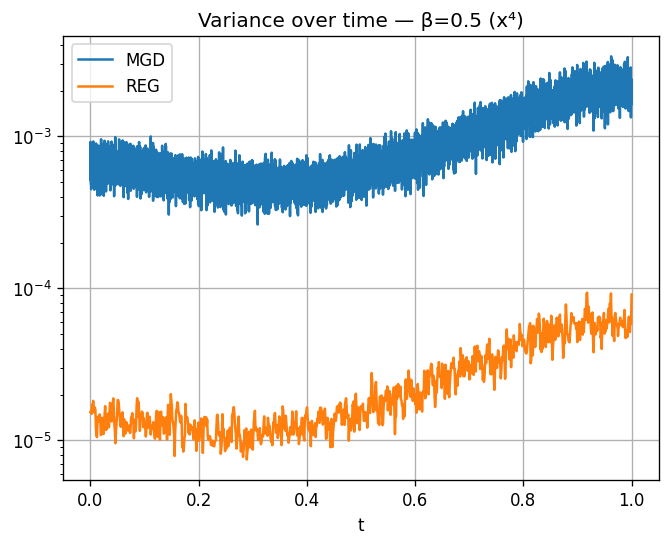

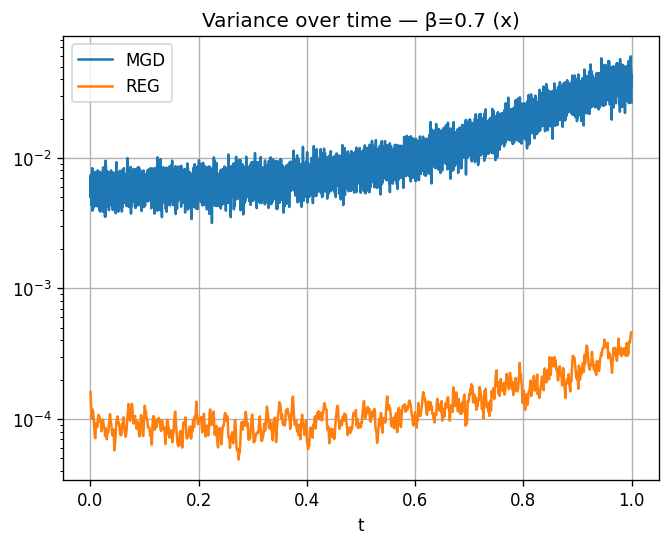

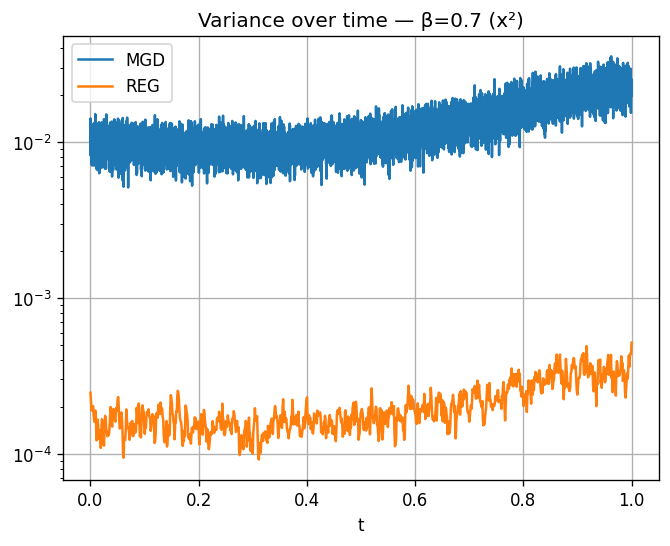

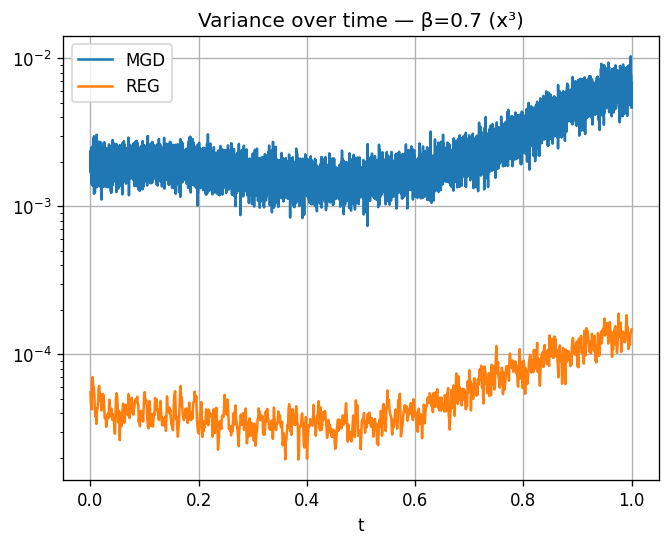

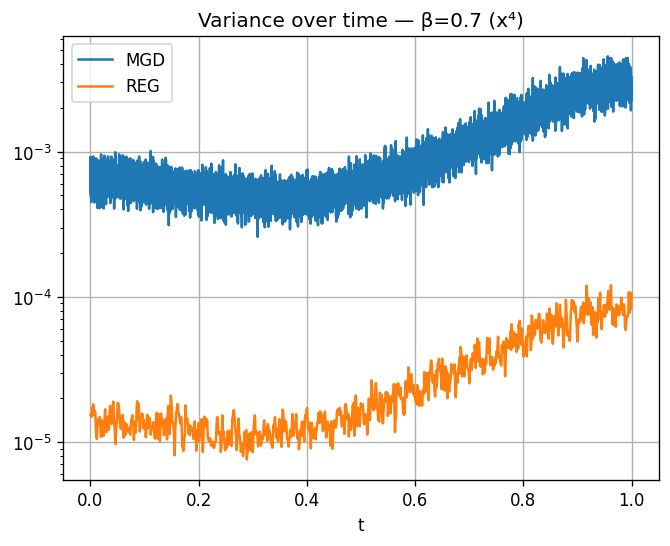

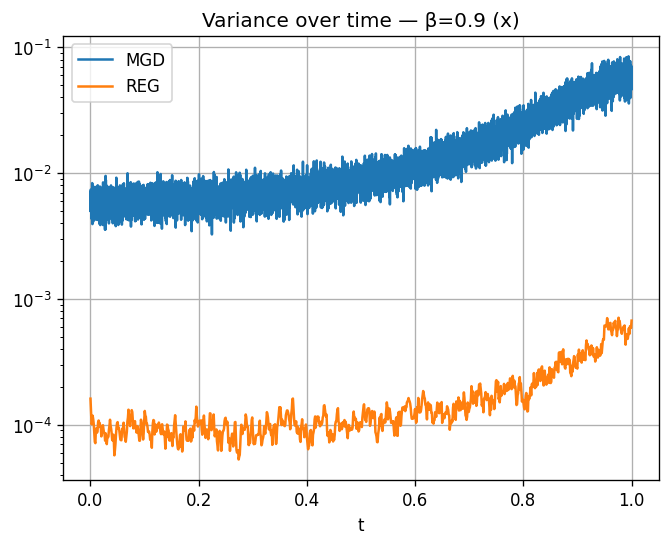

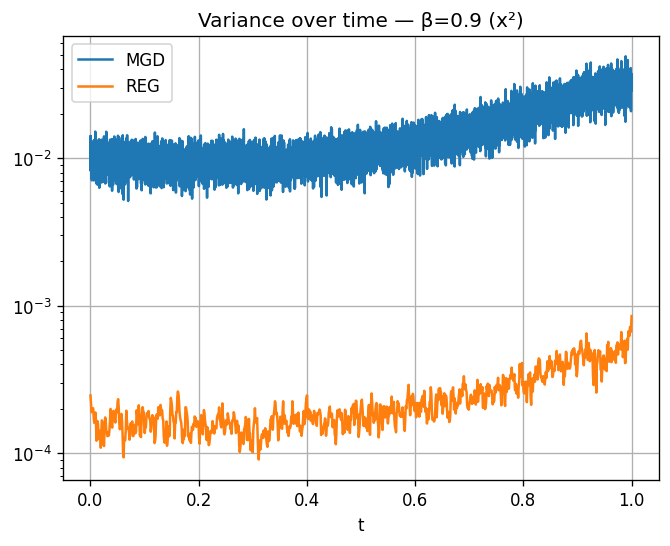

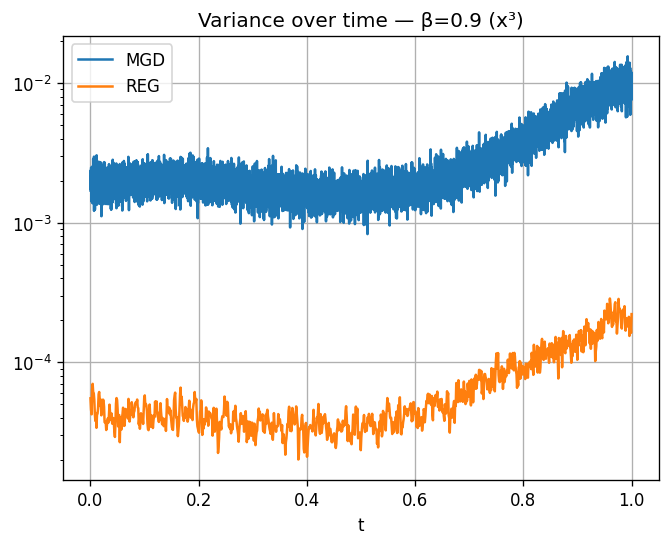

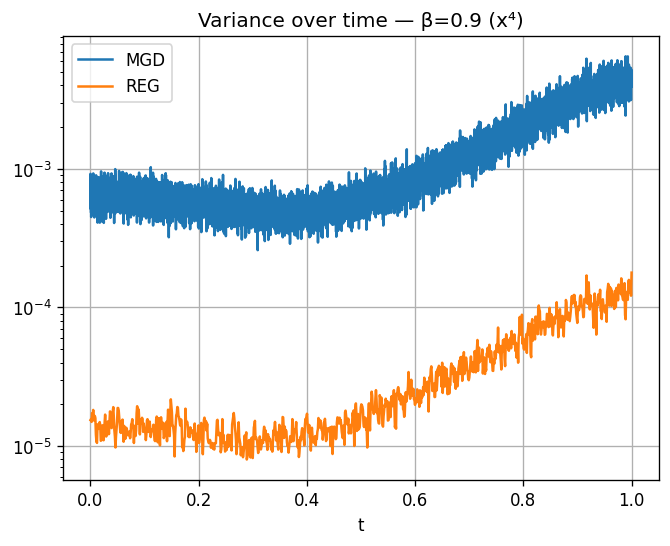

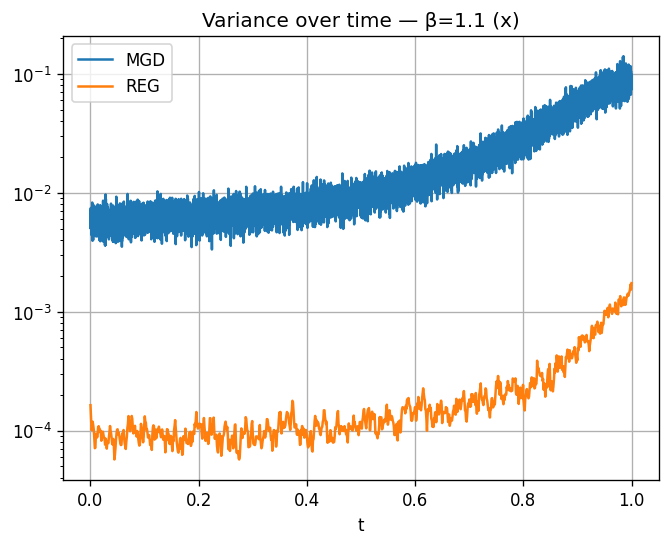

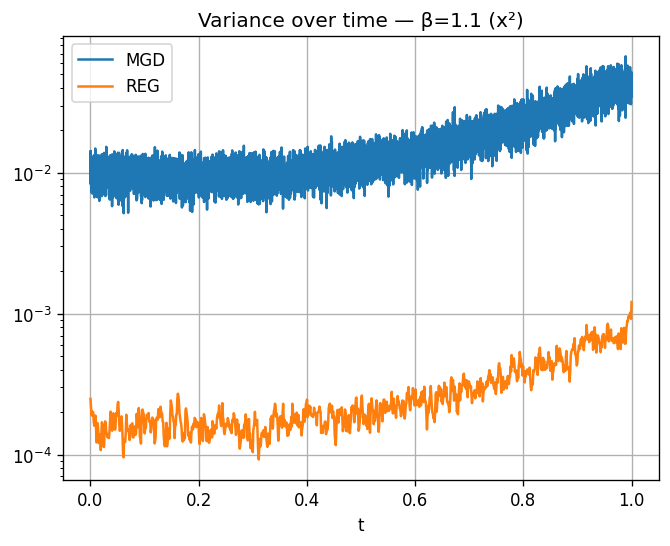

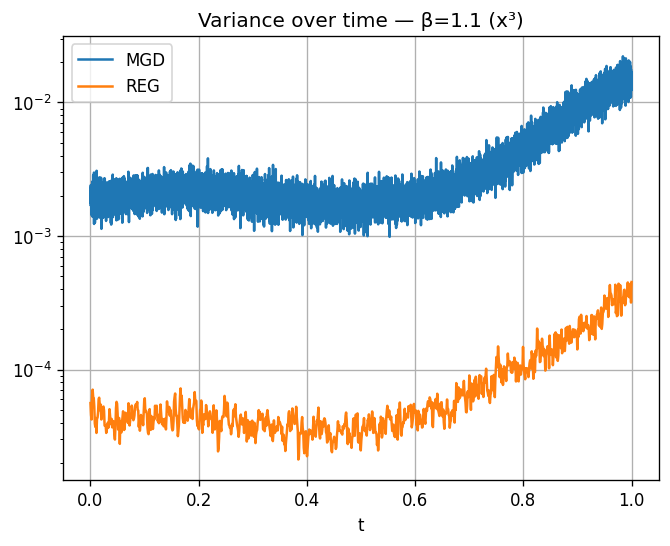

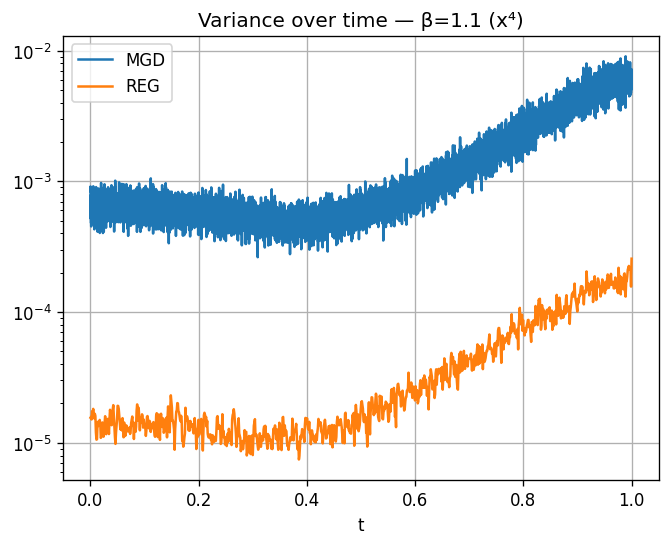

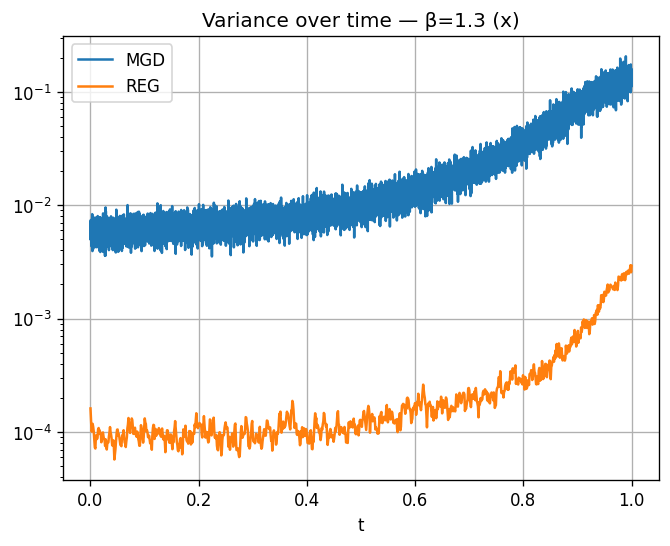

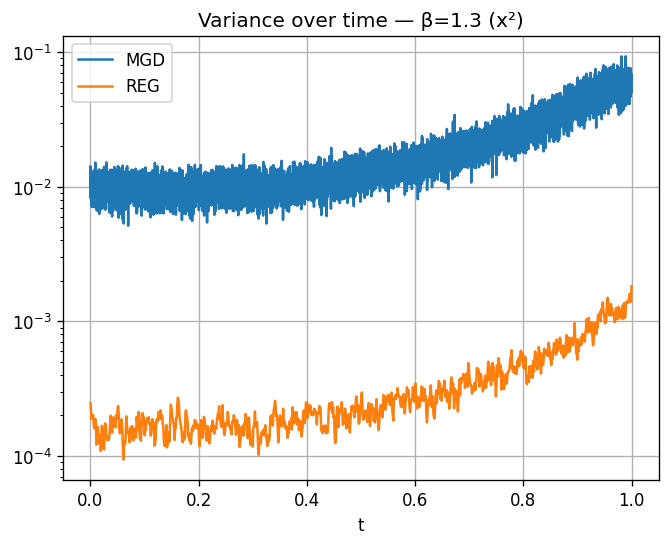

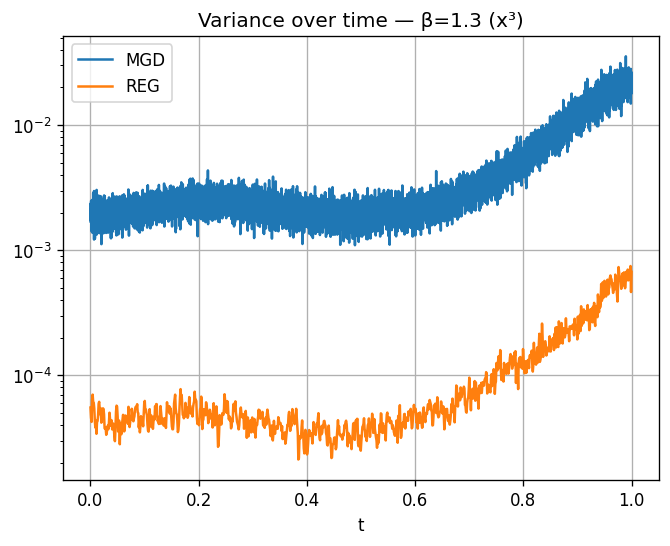

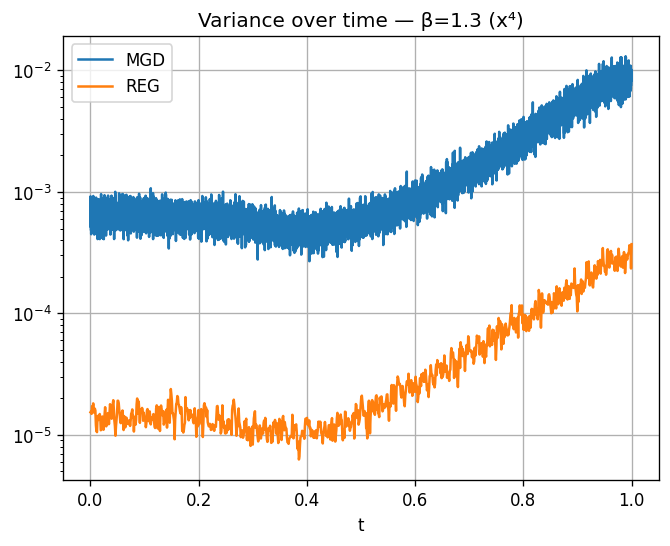

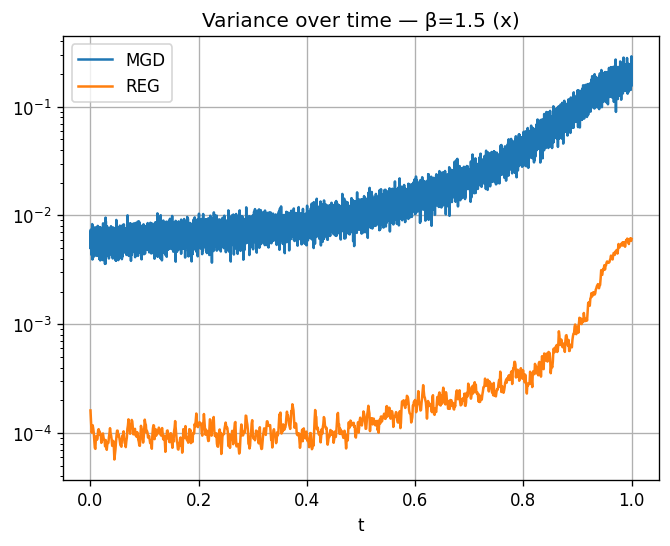

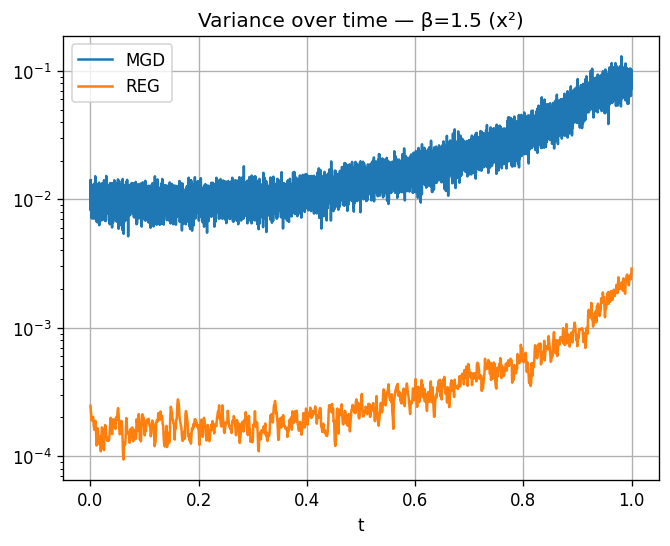

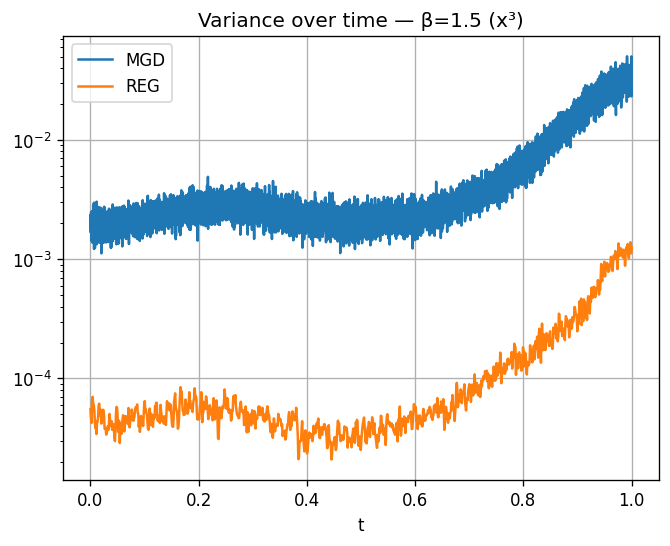

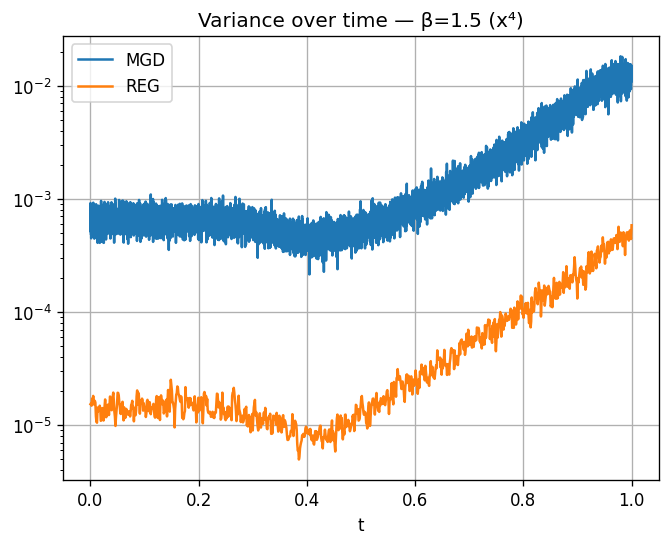

In [37]:
#This tells you where instability happens.

def traj_variance(obj, key):
    return obj[key].var(0)  # variance across K
for beta in selected_betas:
    d = data[beta]

    var_traj_mgd = traj_variance(d, "theta_traj_mgd")
    var_traj_reg = traj_variance(d, "theta_traj_reg")

    t_mgd = np.linspace(0, 1, var_traj_mgd.shape[0])
    t_reg = np.linspace(0, 1, var_traj_reg.shape[0])

    for i in range(4):
        plt.figure()
        plt.plot(t_mgd, var_traj_mgd[:, i], label="MGD")
        plt.plot(t_reg, var_traj_reg[:, i], label="REG")
        plt.yscale("log")
        plt.title(f"Variance over time — β={beta} ({labels[i]})")
        plt.xlabel("t")
        plt.legend()
        plt.grid()
        plt.show()


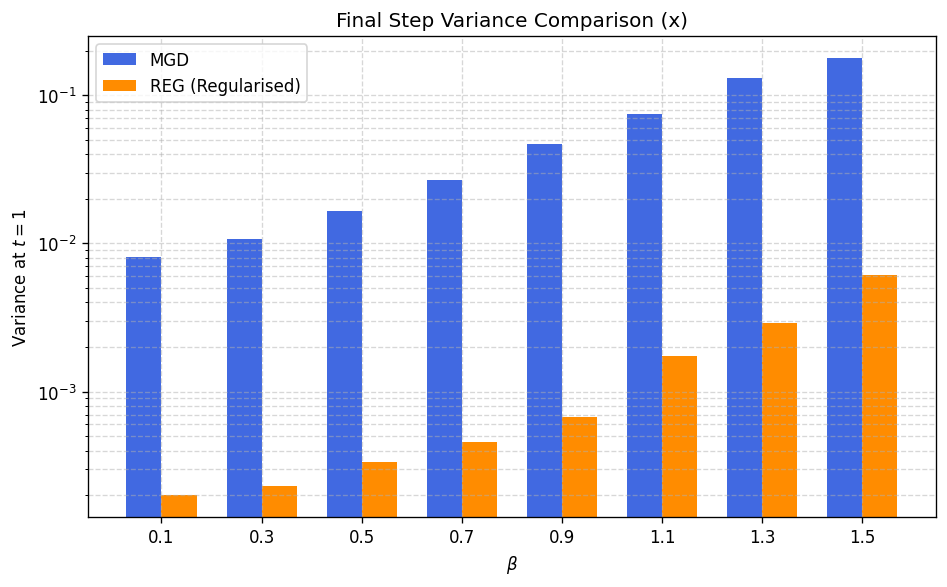

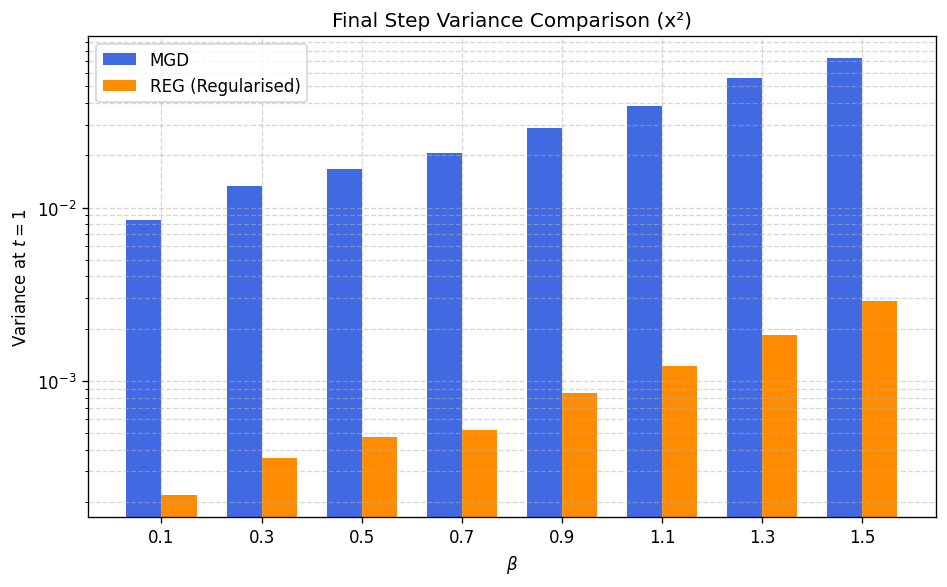

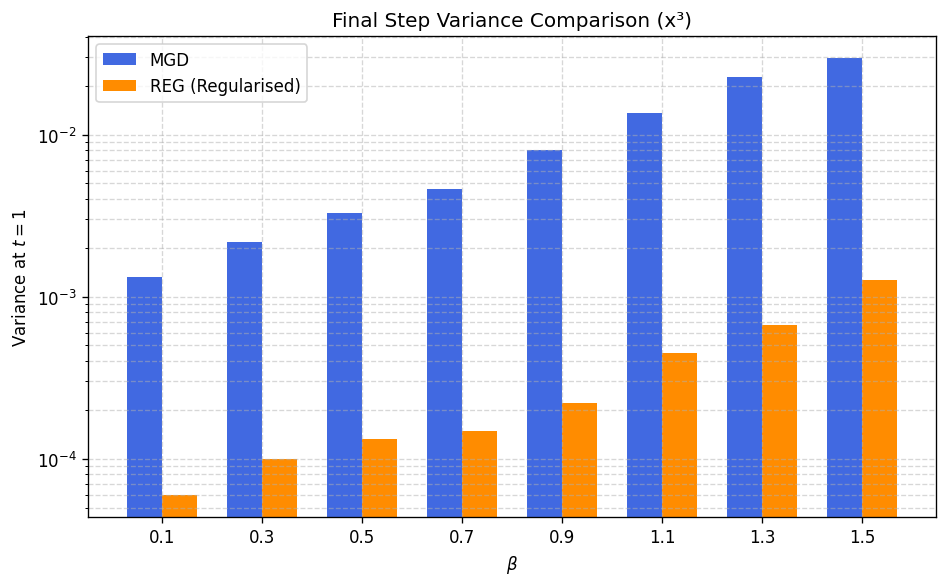

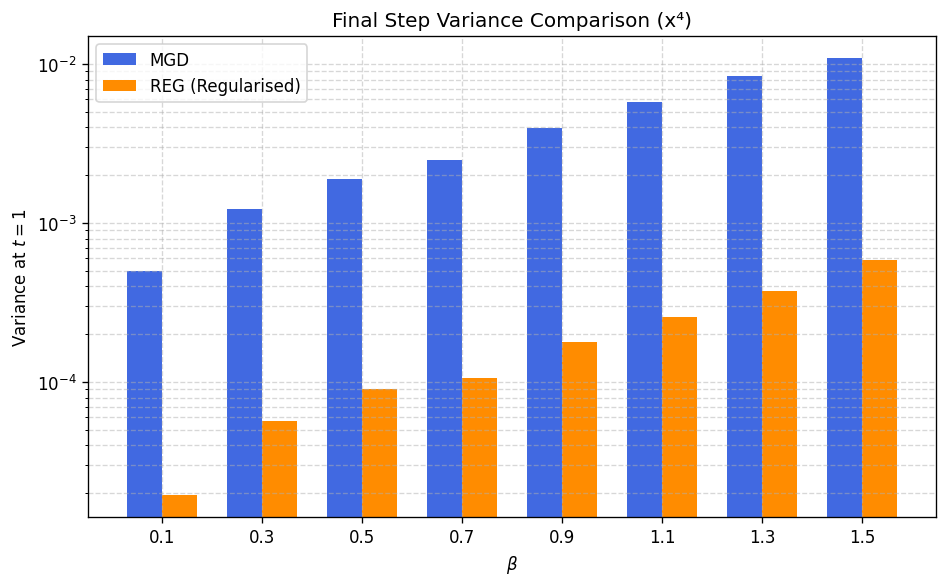

In [38]:
def traj_variance(obj, key):
    return obj[key].var(0)  # variance across K
    
# 1. Collect the final-step variance for all selected betas
final_var_mgd = []
final_var_reg = []

for beta in selected_betas:
    d = data[beta]
    
    # Extract the full trajectory variance over time
    var_traj_mgd = traj_variance(d, "theta_traj_mgd")  # Shape: (nt_mgd, 4)
    var_traj_reg = traj_variance(d, "theta_traj_reg")  # Shape: (nt_reg, 4)
    
    # Grab the very last time step [-1] for each parameter
    final_var_mgd.append(var_traj_mgd[-1].numpy() if hasattr(var_traj_mgd[-1], 'numpy') else var_traj_mgd[-1])
    final_var_reg.append(var_traj_reg[-1].numpy() if hasattr(var_traj_reg[-1], 'numpy') else var_traj_reg[-1])

# Convert to arrays of shape (n_selected_betas, 4)
final_var_mgd = np.array(final_var_mgd)
final_var_reg = np.array(final_var_reg)

# 2. Setup bar plotting parameters
x = np.arange(len(selected_betas))  # Label locations
width = 0.35  # Width of the bars

# 3. Generate the 4 plots
for i in range(4):
    plt.figure(figsize=(8, 5))
    
    # Plot MGD bars on the left, REG bars shifted to the right
    plt.bar(x - width/2, final_var_mgd[:, i], width, label='MGD', color='royalblue')
    plt.bar(x + width/2, final_var_reg[:, i], width, label='REG (Regularised)', color='darkorange')
    
    # Formatting
    plt.yscale("log")  # Highly recommended since instability variances can span orders of magnitude
    plt.xlabel(r"$\beta$")
    plt.ylabel("Variance at $t=1$")
    plt.title(f"Final Step Variance Comparison ({labels[i]})")
    
    # Set the x-ticks to display the actual beta values
    plt.xticks(x, selected_betas)
    
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- Distribution of Thetas around Target ---

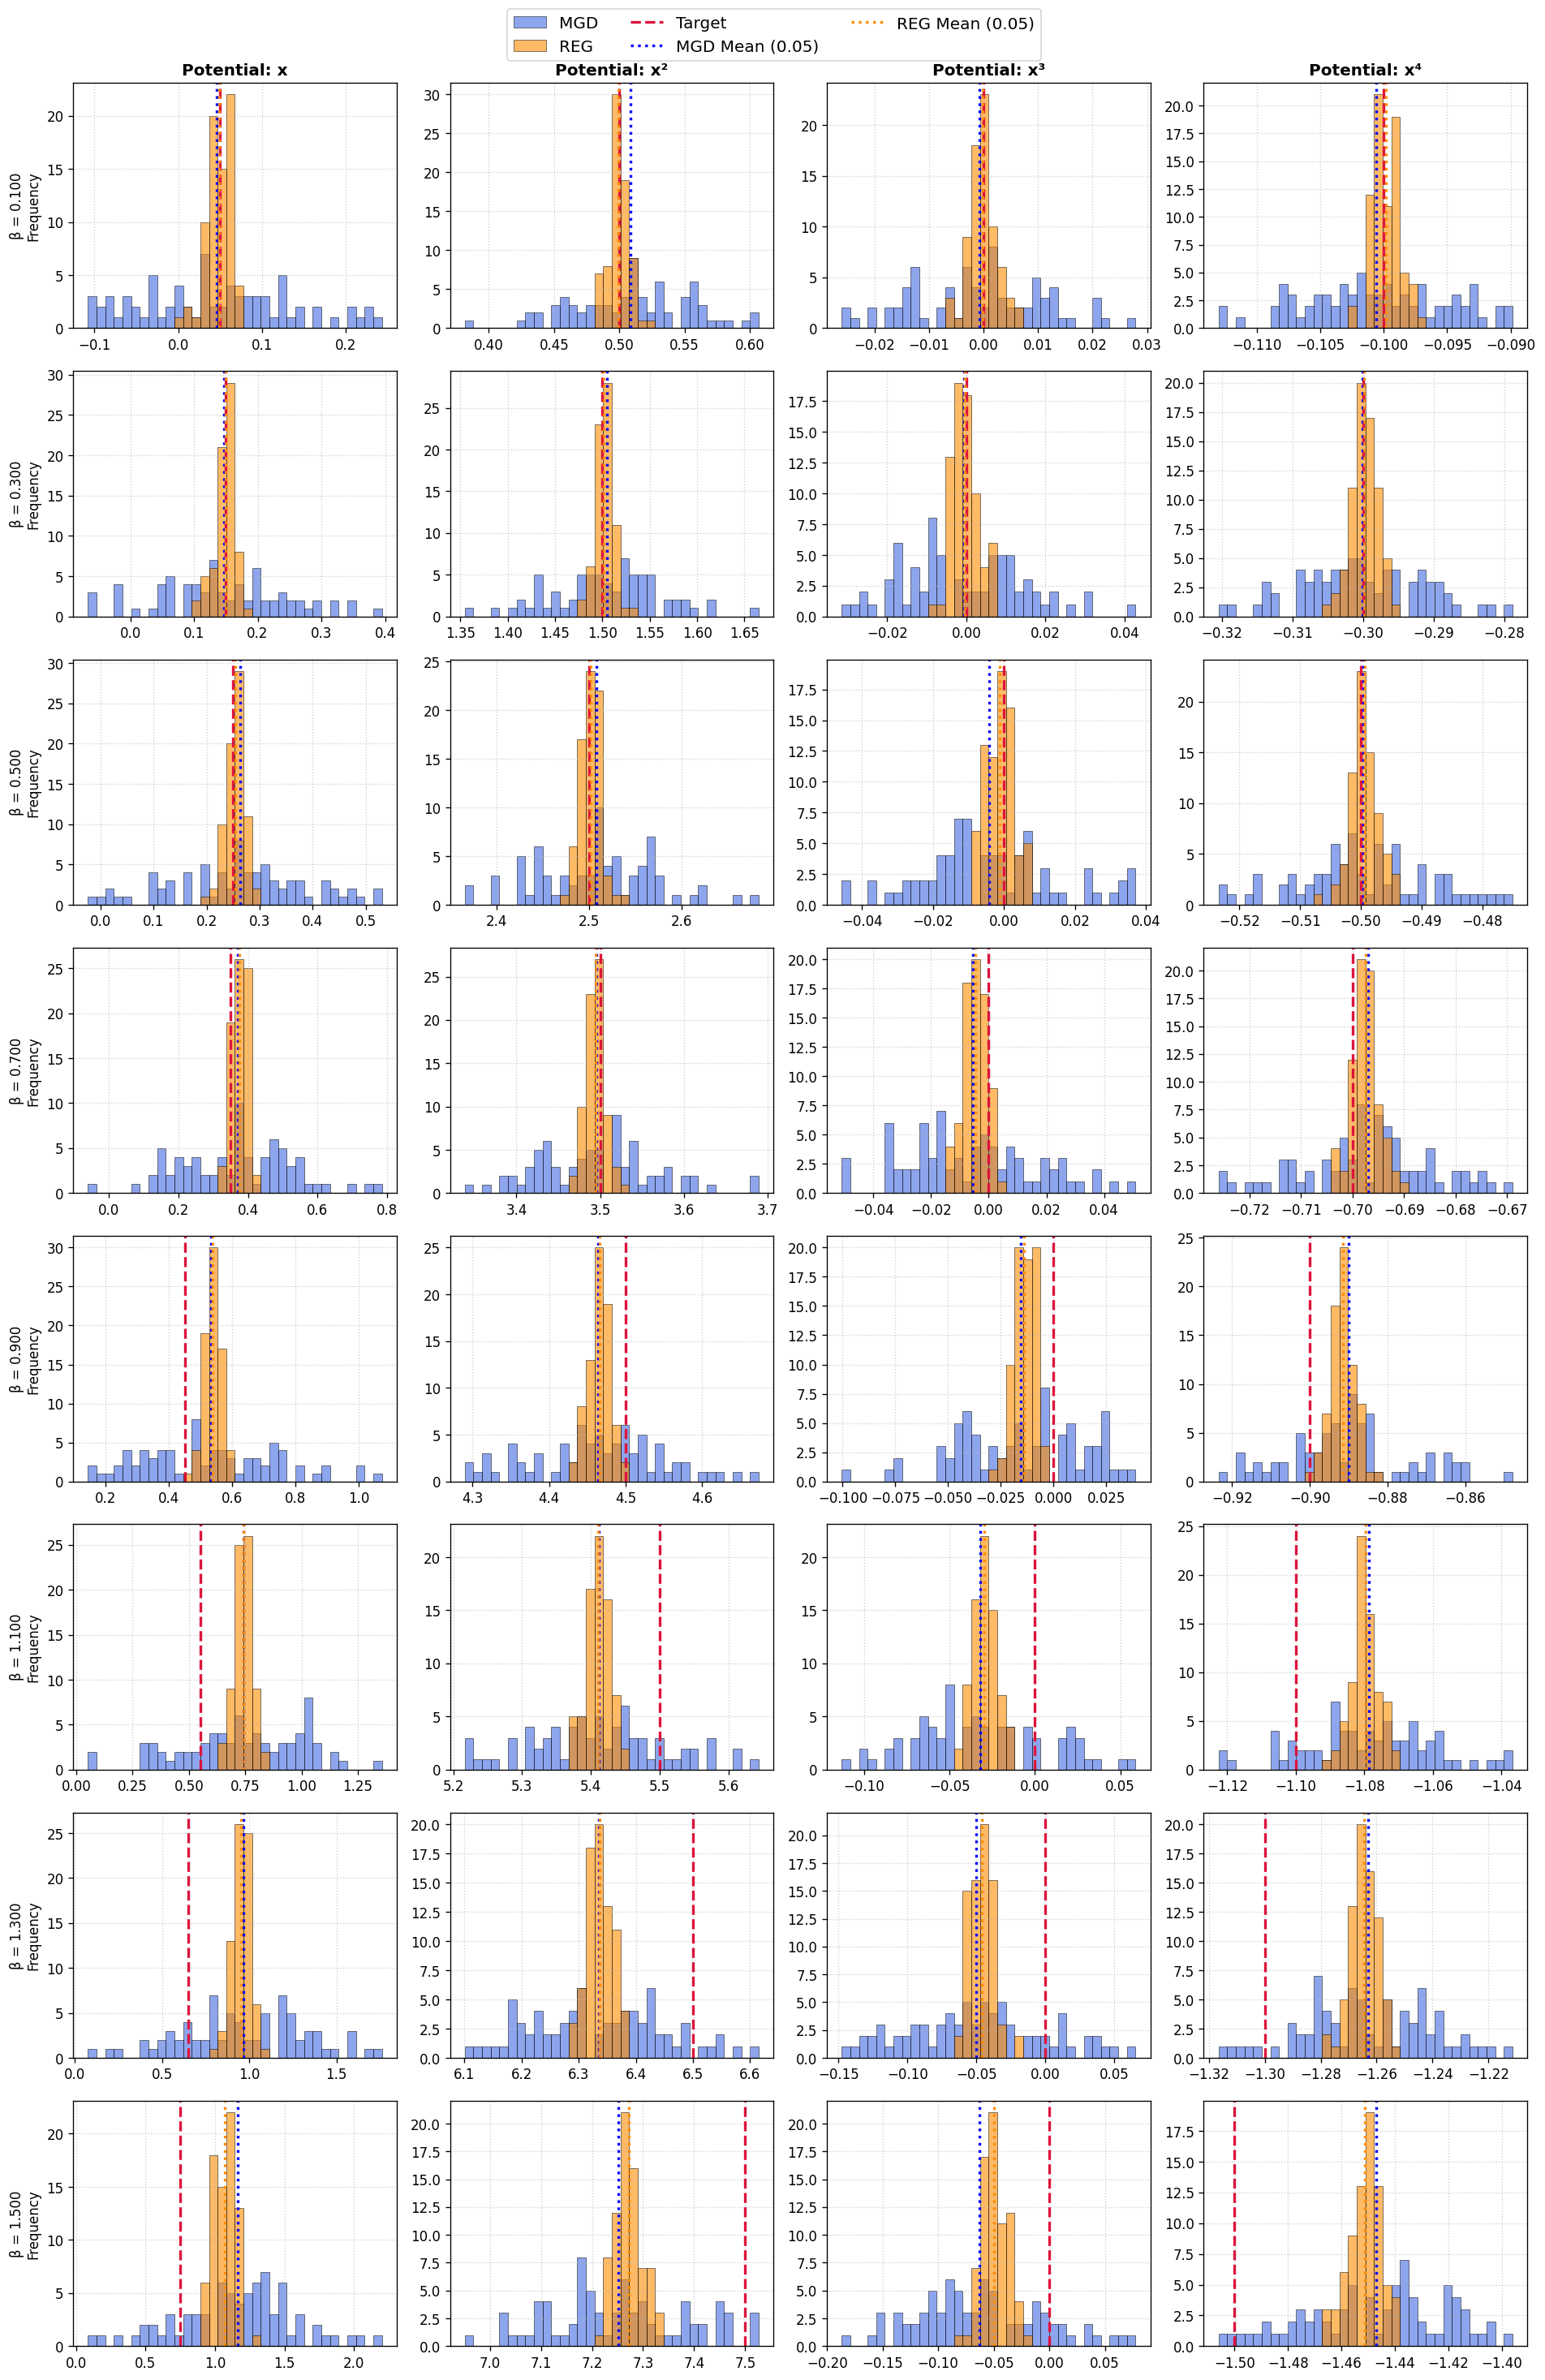

In [39]:
# --- Distribution of Thetas around Target ---

n_betas = len(betas_np)
n_potentials = 4

# Create a large grid of subplots: rows = betas, cols = potentials
fig, axes = plt.subplots(n_betas, n_potentials, figsize=(16, 3 * n_betas), sharey=False)

# Handle the edge case where there's only 1 beta so axes is 1D
if n_betas == 1:
    axes = np.expand_dims(axes, axis=0)

for idx, beta in enumerate(betas_np):
    d = data[beta]
    
    # Extract the raw final theta distributions across all 50 runs (Shape: K, 4)
    # Convert to numpy safely if they are torch tensors
    raw_mgd = d["theta_final_mgd"].cpu().numpy() if torch.is_tensor(d["theta_final_mgd"]) else np.array(d["theta_final_mgd"])
    raw_reg = d["theta_final_reg"].cpu().numpy() if torch.is_tensor(d["theta_final_reg"]) else np.array(d["theta_final_reg"])
    
    # Apply your scaling factor
    scaled_mgd = raw_mgd / scale_factor
    scaled_reg = raw_reg / scale_factor

    for i in range(n_potentials):
        ax = axes[idx, i]
        
        # Grab the specific potential's data across the 50 runs
        mgd_runs = scaled_mgd[:, i]
        reg_runs = scaled_reg[:, i]
        
        # Determine shared bin ranges dynamically based on BOTH distributions
        # This ensures they share the exact same X-axis scale and bin alignment
        min_val = min(mgd_runs.min(), reg_runs.min(), target[idx, i])
        max_val = max(mgd_runs.max(), reg_runs.max(), target[idx, i])
        
        # Bump bins up to 35-40. This allows the tight REG distribution 
        # to split into multiple distinct bars instead of just 1 or 2 chunks.
        bins = np.linspace(min_val, max_val, 35) 
        
        # Plot histograms - CRITICAL: Pass the exact same `bins` array to both!
        ax.hist(mgd_runs, bins=bins, alpha=0.6, label="MGD", color="royalblue", edgecolor="black", linewidth=0.5)
        ax.hist(reg_runs, bins=bins, alpha=0.6, label="REG", color="darkorange", edgecolor="black", linewidth=0.5)
        
        # Add target line
        ax.axvline(target[idx, i], color="crimson", linestyle="--", linewidth=2, label="Target")

        # 1. Calculate the means for this specific beta and potential
        mean_mgd_val = mgd_runs.mean()
        mean_reg_val = reg_runs.mean()

        # 2. Plot the mean lines (place this right after your ax.hist calls)
        ax.axvline(mean_mgd_val, color="blue", linestyle=":", linewidth=2, 
                   label=f"MGD Mean ({mean_mgd_val:.2f})")
        ax.axvline(mean_reg_val, color="darkorange", linestyle=":", linewidth=2, 
                   label=f"REG Mean ({mean_reg_val:.2f})")
        
        # Titles and formatting
        if idx == 0:
            ax.set_title(f"Potential: {labels[i]}", fontsize=12, fontweight='bold')
        if i == 0:
            ax.set_ylabel(f"β = {beta:.3f}\nFrequency", fontsize=10)
            
        ax.grid(True, linestyle=":", alpha=0.6)

# Add a single unified legend at the top of the entire figure
handles, labels_legend = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12)

plt.tight_layout()
plt.show()

# KL analysis 

=== Coherence check: utils.integrand vs. log_p_unnorm + target_theta ===
beta=  0.100 | KL(true || exact target) = -3.998e-15  [OK]
beta=  0.300 | KL(true || exact target) = -1.533e-17  [OK]
beta=  0.500 | KL(true || exact target) = -3.397e-13  [OK]
beta=  0.700 | KL(true || exact target) = -1.468e-17  [OK]
beta=  0.900 | KL(true || exact target) = -1.768e-15  [OK]
beta=  1.100 | KL(true || exact target) = 8.689e-17  [OK]
beta=  1.300 | KL(true || exact target) = 4.183e-16  [OK]
beta=  1.500 | KL(true || exact target) = -1.946e-15  [OK]


β = 0.1
MGD final : 6.370e-03 ± 5.935e-03
REG final : 1.209e-04 ± 1.077e-04

β = 0.3
MGD final : 7.259e-03 ± 8.743e-03
REG final : 1.205e-04 ± 1.328e-04

β = 0.5
MGD final : 9.327e-03 ± 1.051e-02
REG final : 1.520e-04 ± 1.656e-04

β = 0.7
MGD final : 1.342e-02 ± 1.593e-02
REG final : 4.186e-04 ± 4.519e-04

β = 0.9
MGD final : 1.785e-02 ± 2.163e-02
REG final : 2.367e-03 ± 1.247e-03

β = 1.1
MGD final : 2.459e-02 ± 2.715e-02
REG final : 8.401e-03 ± 3.34

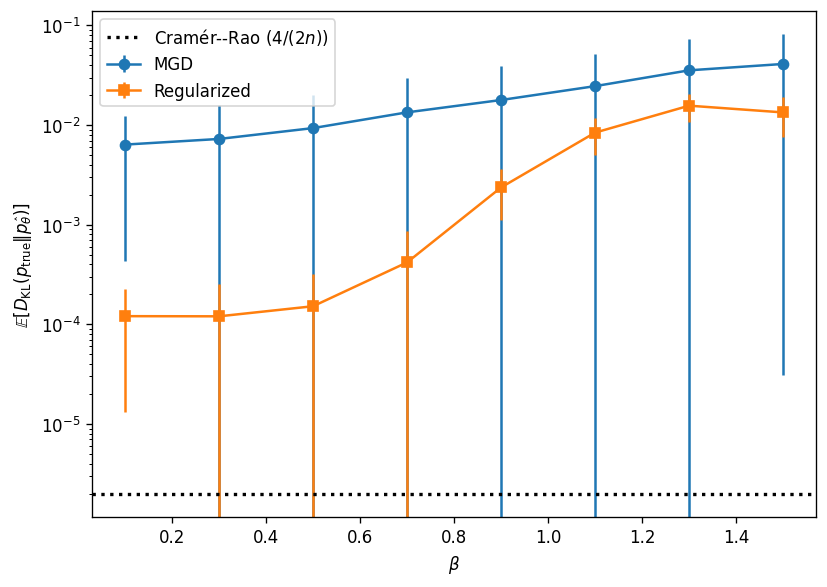

In [13]:
"""
kl_divergence_analysis.py
 
Post-hoc normalization + KL divergence computation for the scalar bimodal MGD experiment (bimodal_ensemble_reg.py). Run entirely at analysis time from saved results -- no need to redraw x1 or touch solve_sde.

Convention (matching target_theta in bimodal_ensemble_reg.py): p_theta(x) = (1/Z(theta)) * exp(theta[0]*x + theta[1]*x**2  + theta[2]*x**3 + theta[3]*x**4)
i.e. theta are the natural parameters (Lagrange multipliers) of an exponential family with sufficient statistics phi(x) = [x, x^2, x^3, x^4] --
NOT a negative-log-density / "energy" convention. theta[3] must be < 0 for p_theta to be normalizable (confining quartic term), which matches
target_theta[3] = -beta with beta > 0.
 
If potentials_1d.py instead defines U(x) = -sum_a theta_a x^a (energy convention, density = exp(-U)), negate theta before calling these functions.
"""
from scipy import integrate
from scipy.integrate import quad, simpson
 
# ----------------------------------------------------------------------
# 1. Unnormalized log-density / normalizing constant for a given theta
# ----------------------------------------------------------------------
def log_p_unnorm(x, theta):
    return theta[0] * x + theta[1] * (x**2 / 2) + theta[2] * (x**3 / 3) + theta[3] * (x**4 / 4)
 
def log_Z(theta, x_range=(-50.0, 50.0), n_grid=4001):
    """
    Z(theta) = integral of exp(log_p_unnorm(x, theta)) dx, via Simpson's rule on a fixed grid (log-sum-exp shifted to avoid overflow).
 
    NOTE: this used to call scipy.integrate.quad on top of the grid that was already built just to find the max `m`. quad's adaptive subdivision struggles badly with a function that is a sharp spike sitting inside a huge flat-zero tail (exactly what a quartic-confined density looks like over +/-50) -- it keeps refining trying to resolve "structure" in floating point noise, which is the source of the IntegrationWarning roundoff messages and a lot of wasted time. Simpson on the grid we already have is both faster and avoids that failure mode. """
    grid = np.linspace(*x_range, n_grid)
    log_vals = log_p_unnorm(grid, theta)
    m = log_vals.max()
    vals = np.exp(log_vals - m)
 
    val = simpson(vals, x=grid)
    if val <= 0 or not np.isfinite(val):
        raise RuntimeError(
            f"Z integration failed (val={val}); "
            f"check theta sign/x_range: {theta}"
        )
    return m + np.log(val)
 
 
def normalized_log_p_theta(x, theta, x_range=(-50.0, 50.0)):
    return log_p_unnorm(x, theta) - log_Z(theta, x_range=x_range)
 
def make_log_p_true(beta):
    """
    Returns a *vectorized* log p_true(x) (accepts scalars or arrays), which kl_divergence below relies on to evaluate the whole grid in one shot.
    The np.errstate just silences the (harmless, expected) "divide by zero" warning for x where the true density has genuinely underflowed to 0 --
    log(0) = -inf IS the correct value there, we just don't want numpy printing a warning about it every time. """
    Z, _ = quad(integrand, -np.inf, np.inf, args=(beta,))
    logZ = np.log(Z)
 
    def log_p_true(x):
        x = np.asarray(x, dtype=float)
        vals = integrand(x, beta)
        with np.errstate(divide="ignore"):
            return np.log(vals) - logZ
 
    return log_p_true
 
# ----------------------------------------------------------------------
# 2. KL(p_true || p_theta) given an analytic true density
# ----------------------------------------------------------------------
 
def kl_divergence(log_p_true, theta, x_range=(-50.0, 50.0), n_grid=4001):
    """
    KL(p_true || p_theta), via Simpson's rule on a fixed grid.
 
    THE BUG: the old version used scipy.integrate.quad with a pointwise integrand `p_true_x * (log_p_true(x) - log_p_unnorm(x, theta) + lZ)`. Anywhere the true density underflows to exactly 0.0 in float64 (which always happens somewhere in a +/-50 window for a confined density),
    log_p_true(x) = -inf -> p_true_x = exp(-inf) = 0.0, but the second factor is also -inf, so you get IEEE `0.0 * (-inf) = nan` ("invalid value encountered in multiply"). Mathematically the limit of p*log(p) as p->0 is 0 (the standard information-theory convention
    0*log(0):=0), but a bare 0*(-inf) doesn't know that -- it's just NaN. A single NaN return poisons quad's adaptive subdivision: it can't get a stable error estimate, so it keeps splitting (hence the roundoff warnings) and chews through its evaluation budget on every single
    call -- with thousands of calls (K runs x nt timesteps x 2 estimators x n_beta) that's exactly the "runs forever with no result" symptom. FIX: evaluate on a fixed grid and explicitly zero out the contribution wherever p_true == 0, enforcing 0*log(0):=0 directly instead of letting
    floating point arithmetic try to discover it. """
    # If the quartic coefficient is non-negative, it's not integrable on R
    if theta[3] >= 0:
        return np.nan
 
    try:
        lZ = log_Z(theta, x_range=x_range, n_grid=n_grid)
    except RuntimeError:
        return np.nan
 
    grid = np.linspace(*x_range, n_grid)
    with np.errstate(divide="ignore", invalid="ignore"):
        log_pt = log_p_true(grid)                 # -inf where p_true underflows to 0
        p_true = np.exp(log_pt)                    # 0.0 there
        log_pth = log_p_unnorm(grid, theta) - lZ
        vals = p_true * (log_pt - log_pth)
    vals = np.where(p_true > 0, vals, 0.0)          # enforce 0*log(0) := 0
 
    return simpson(vals, x=grid)
 
 
# ----------------------------------------------------------------------
# 2b. Vectorized/batched versions: compute log_Z and KL for an entire
#     (M, 4) array of thetas in ONE shot, instead of looping scalar-by-
#     -scalar. This is the actual performance fix for analyze() below:
#     with K runs x nt timesteps, the scalar loop makes K*nt separate
#     calls, each rebuilding the same grid and recomputing the (constant,
#     theta-independent) true density from scratch. Batching collapses
#     all of that into a handful of vectorized array ops.
# ----------------------------------------------------------------------
 
def _phi_basis(grid):
    """phi(x) = [x, x^2/2, x^3/3, x^4/4], shape (n_grid, 4), matching log_p_unnorm."""
    return np.stack([grid, grid**2 / 2, grid**3 / 3, grid**4 / 4], axis=1)
 
 
def log_Z_batch(thetas, grid, phi=None):
    """
    thetas: (M, 4) array -- M theta vectors evaluated at once.  grid:   (n_grid,) fixed grid, built ONCE outside any loop.
    Returns logZ: (M,), log_vals: (M, n_grid) (the latter reused by kl_divergence_batch to avoid recomputing log_p_unnorm twice). """
    if phi is None:
        phi = _phi_basis(grid)                       # (n_grid, 4)
    log_vals = thetas @ phi.T                          # (M, n_grid)
    m = log_vals.max(axis=1, keepdims=True)            # (M, 1)
    with np.errstate(over="ignore", invalid="ignore"):
        vals = np.exp(log_vals - m)
        Z_shifted = simpson(vals, x=grid, axis=1)          # (M,)
        logZ = m[:, 0] + np.log(Z_shifted)
    return logZ, log_vals
 
 
def _kl_divergence_batch_core(p_true_grid, log_p_true_grid, thetas, grid, phi):
    """One unchunked batch -- only safe to call directly on a SMALL number
    of rows at a time (a few thousand at most); see kl_divergence_batch."""
    bad = thetas[:, 3] >= 0
    logZ, log_vals = log_Z_batch(thetas, grid, phi=phi)   # (M,), (M, n_grid)
    log_pth = log_vals - logZ[:, None]                     # (M, n_grid)
 
    with np.errstate(invalid="ignore"):
        integrand_vals = p_true_grid[None, :] * (log_p_true_grid[None, :] - log_pth)
    integrand_vals = np.where(p_true_grid[None, :] > 0, integrand_vals, 0.0)
 
    kl = simpson(integrand_vals, x=grid, axis=1)
    return np.where(bad, np.nan, kl)
 
 
def kl_divergence_batch(p_true_grid, log_p_true_grid, thetas, grid, phi=None, chunk_size=1000):
    """
    p_true_grid, log_p_true_grid: (n_grid,) -- precomputed ONCE per beta,  outside this function (p_true doesn't depend on theta). thetas: (M, 4) -- e.g. theta_final_mgd, or theta_traj_mgd reshaped to (K*nt, 4). M can be large: with K~30 runs and nt_mgd~10000 saved
        steps, M = K*nt_mgd ~ 300000. Returns kl: (M,) array (NaN wherever theta[:,3] >= 0, same convention as the scalar kl_divergence).
 
    Processed in chunks of `chunk_size` rows. This is NOT just a memory safety margin -- holding the full (M, n_grid) intermediate array in one shot can be genuinely huge: a (300000, 4001) float64 array alone is ~9 GB, and several such temporaries get allocated per call, which is enough to raise a MemoryError (confirmed by testing) even on a generously-provisioned node. Chunking at ~500-2000 rows keeps peak
    memory at a few tens of MB and was empirically *faster* too (better cache behaviour than one giant array), not merely safer. """
    thetas = np.asarray(thetas, dtype=float)
    M = thetas.shape[0]
    if phi is None:
        phi = _phi_basis(grid)
 
    out = np.empty(M)
    for start in range(0, M, chunk_size):
        end = min(start + chunk_size, M)
        out[start:end] = _kl_divergence_batch_core(
            p_true_grid, log_p_true_grid, thetas[start:end], grid, phi
        )
    return out
    return np.where(bad, np.nan, kl)
 
 
# ----------------------------------------------------------------------
# 1.5 Coherence check: are p_true (utils.integrand) and p_theta
#     (log_p_unnorm + theta_final_*) actually the same family/basis?
# ----------------------------------------------------------------------
 
def sanity_check_convention(beta, x_range=(-50.0, 50.0)):
    """
    Plugs the EXACT target potential into log_p_unnorm (converted into its
    basis: log_p_unnorm uses phi(x) = [x, x^2/2, x^3/3, x^4/4], whereas
    target = [beta/2, 5*beta, 0, -beta] earlier in this script is expressed
    in the [x, x^2, x^3, x^4] basis -- hence the `* scale_factor` below,
    which is the exact inverse of the `/ scale_factor` used for mean_mgd /
    mean_reg further up) and checks KL(p_true || p_target) ~ 0.
 
    If this prints ~0 (think < 1e-3), utils.integrand and log_p_unnorm +
    target_theta describe the SAME distribution and everything downstream
    (theta_final_mgd/reg plugged straight into log_p_unnorm) is coherent.
    If it does NOT go to ~0, there's a real basis/sign mismatch between
    utils.integrand and target_theta (e.g. an energy-vs-natural-parameter
    sign flip, or a missing factor) and the KL numbers below are not
    measuring what you think they are -- that needs fixing in utils.py /
    bimodal_ensemble_reg.py before trusting any KL value here.
    """
    scale_factor = np.array([1, 2, 3, 4])
    target_no_div = np.array([beta / 2, 5 * beta, 0.0, -beta])  # basis x, x^2, x^3, x^4
    target_raw = target_no_div * scale_factor                   # -> log_p_unnorm's basis
 
    log_p_true = make_log_p_true(beta)
    kl = kl_divergence(log_p_true, target_raw, x_range=x_range)
    flag = "OK" if (np.isfinite(kl) and kl < 1e-3) else "!! CONVENTION MISMATCH !!"
    print(f"beta={beta:>7.3f} | KL(true || exact target) = {kl:.3e}  [{flag}]")
    return kl
 
def make_log_p_theta_mean(theta_mean, x_range=(-50.0, 50.0), n_grid=4001):
    """
    Returns a vectorized function evaluating the normalized log-density 
    of p_theta using the averaged theta vector across runs.
    """
    # Precompute log_Z for the mean theta to avoid recomputing it on every call
    lZ = log_Z(theta_mean, x_range=x_range, n_grid=n_grid)
    
    def log_p_theta_mean(x):
        x = np.asarray(x, dtype=float)
        return log_p_unnorm(x, theta_mean) - lZ
        
    return log_p_theta_mean


def analyze_vs_theta_mean(data, beta, x_range=(-50.0, 50.0), n_grid=4001, compute_trajectory=False, trajectory_stride=1):
    """
    Computes KL divergence where the reference distribution is p_{theta_mean}
    instead of the theoretical p_true.
    """
    theta_final_mgd = data[beta]["theta_final_mgd"].numpy()  # Shape: (K, 4)
    theta_final_reg = data[beta]["theta_final_reg"].numpy()  # Shape: (K, 4)

    # 1. Compute the average theta across all K runs
    theta_mean_mgd = theta_final_mgd.mean(axis=0)
    theta_mean_reg = theta_final_reg.mean(axis=0)

    # 2. Setup the evaluation grid
    grid = np.linspace(*x_range, n_grid)
    phi = _phi_basis(grid)

    # 3. Create the log_p reference functions for both methods
    log_p_ref_mgd_func = make_log_p_theta_mean(theta_mean_mgd, x_range=x_range, n_grid=n_grid)
    log_p_ref_reg_func = make_log_p_theta_mean(theta_mean_reg, x_range=x_range, n_grid=n_grid)

    # 4. Evaluate reference densities on the grid
    log_p_ref_mgd_grid = log_p_ref_mgd_func(grid)
    p_ref_mgd_grid = np.exp(log_p_ref_mgd_grid)

    log_p_ref_reg_grid = log_p_ref_reg_func(grid)
    p_ref_reg_grid = np.exp(log_p_ref_reg_grid)

    # 5. Compute Final KL using the batched framework
    kl_mgd = kl_divergence_batch(p_ref_mgd_grid, log_p_ref_mgd_grid, theta_final_mgd, grid, phi=phi)
    kl_reg = kl_divergence_batch(p_ref_reg_grid, log_p_ref_reg_grid, theta_final_reg, grid, phi=phi)

    # 6. Optional Trajectory KL
    kl_traj_mgd, kl_traj_reg = None, None
    if compute_trajectory:
        theta_traj_mgd = data[beta]["theta_traj_mgd"].numpy()
        theta_traj_reg = data[beta]["theta_traj_reg"].numpy()
    
        theta_traj_mgd_ds = theta_traj_mgd[:, ::trajectory_stride, :]
        theta_traj_reg_ds = theta_traj_reg[:, ::trajectory_stride, :]
    
        K, nt_mgd, _ = theta_traj_mgd_ds.shape
        _, nt_reg, _ = theta_traj_reg_ds.shape
    
        kl_traj_mgd = kl_divergence_batch(
            p_ref_mgd_grid, log_p_ref_mgd_grid, theta_traj_mgd_ds.reshape(-1, 4), grid, phi=phi
        ).reshape(K, nt_mgd)
    
        kl_traj_reg = kl_divergence_batch(
            p_ref_reg_grid, log_p_ref_reg_grid, theta_traj_reg_ds.reshape(-1, 4), grid, phi=phi
        ).reshape(K, nt_reg)
    
    print(f"\nβ = {beta} (Relative to Mean Theta Distribution)")
    print(f"MGD final vs Mean MGD: {kl_mgd.mean():.3e} ± {kl_mgd.std():.3e}")
    print(f"REG final vs Mean REG: {kl_reg.mean():.3e} ± {kl_reg.std():.3e}")
 
    return kl_mgd, kl_reg, kl_traj_mgd, kl_traj_reg
    
# ----------------------------------------------------------------------
# 3. Apply to saved K-run results (this is the part you run post-hoc)
# ----------------------------------------------------------------------
 
def analyze(data, beta, log_p_true, x_range=(-50.0, 50.0), n_grid=4001, compute_trajectory=False, trajectory_stride=1):
    """
    Computes:
      - KL for the final estimator of each run.
      - KL trajectory for every run and every time point.
 
    Vectorized: the grid and the true density (both independent of theta)
    are built ONCE here, and every batch of thetas (finals, and the full
    K x nt trajectories) is passed through kl_divergence_batch in a single
    vectorized call -- no per-(k,t) Python loop, no per-call grid rebuild.
 
    Returns
    -------
    kl_mgd : (K,)
    kl_reg : (K,)
    kl_traj_mgd : (K, nt_mgd)
    kl_traj_reg : (K, nt_reg)
    """
    theta_final_mgd = data[beta]["theta_final_mgd"].numpy()
    theta_final_reg = data[beta]["theta_final_reg"].numpy()
 
    # -------------------------------------------------------
    # Build the grid and the TRUE density ONCE for this beta.
    # Neither depends on theta, so this must not be inside any
    # per-theta loop.
    # -------------------------------------------------------
    grid = np.linspace(*x_range, n_grid)
    phi = _phi_basis(grid)
    with np.errstate(divide="ignore"):
        log_p_true_grid = log_p_true(grid)
    p_true_grid = np.exp(log_p_true_grid)
 
    # -------------------------------------------------------
    # Final KL (one batched call per estimator, size (K,))
    # -------------------------------------------------------
    kl_mgd = kl_divergence_batch(p_true_grid, log_p_true_grid, theta_final_mgd, grid, phi=phi)
    kl_reg = kl_divergence_batch(p_true_grid, log_p_true_grid, theta_final_reg, grid, phi=phi)
 
    # -------------------------------------------------------
    # Optional KL trajectory: flatten (K, nt, 4) -> (K*nt, 4), one batched
    # call, then reshape back to (K, nt). This replaces the
    # K*nt_mgd + K*nt_reg scalar kl_divergence calls with two
    # vectorized calls total.
    # -------------------------------------------------------
    if compute_trajectory:

        theta_traj_mgd = data[beta]["theta_traj_mgd"].numpy()
        theta_traj_reg = data[beta]["theta_traj_reg"].numpy()
    
        theta_traj_mgd_ds = theta_traj_mgd[:, ::trajectory_stride, :]
        theta_traj_reg_ds = theta_traj_reg[:, ::trajectory_stride, :]
    
        K, nt_mgd, _ = theta_traj_mgd_ds.shape
        _, nt_reg, _ = theta_traj_reg_ds.shape
    
        kl_traj_mgd = kl_divergence_batch(
            p_true_grid,
            log_p_true_grid,
            theta_traj_mgd_ds.reshape(-1, 4),
            grid,
            phi=phi,
        ).reshape(K, nt_mgd)
    
        kl_traj_reg = kl_divergence_batch(
            p_true_grid,
            log_p_true_grid,
            theta_traj_reg_ds.reshape(-1, 4),
            grid,
            phi=phi,
        ).reshape(K, nt_reg)
    
    else:
    
        kl_traj_mgd = None
        kl_traj_reg = None
 
    print(f"\nβ = {beta}")
    print(f"MGD final : {kl_mgd.mean():.3e} ± {kl_mgd.std():.3e}")
    print(f"REG final : {kl_reg.mean():.3e} ± {kl_reg.std():.3e}")
 
    return (
        kl_mgd,
        kl_reg,
        kl_traj_mgd,
        kl_traj_reg,
    )

import pickle 

 
print("=== Coherence check: utils.integrand vs. log_p_unnorm + target_theta ===")
for beta in betas_np:
    sanity_check_convention(beta)
print()
 
summary = []
 
for beta in betas_np:
 
    log_p_true = make_log_p_true(beta)
 
    kl_mgd, kl_reg, traj_mgd, traj_reg = analyze(
        data,
        beta,
        log_p_true,
        compute_trajectory=True,
        trajectory_stride=100,
    )
 
    summary.append({
        "beta": beta,
        "kl_mgd": kl_mgd,
        "kl_reg": kl_reg,
        "traj_mgd": traj_mgd,
        "traj_reg": traj_reg,
    })

# -------------------------------------------------------
# Save all expensive results
# -------------------------------------------------------
with open("kl_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

print("Saved KL results to kl_summary.pkl")

# -------------------------------------------------------
# Plot
# -------------------------------------------------------

betas = [r["beta"] for r in summary]

kl_mgd_mean = [r["kl_mgd"].mean() for r in summary]
kl_mgd_std  = [r["kl_mgd"].std()  for r in summary]

kl_reg_mean = [r["kl_reg"].mean() for r in summary]
kl_reg_std  = [r["kl_reg"].std()  for r in summary]

# all experiments use the same n1
n1 = data[betas[0]]["config"]["n1"]
cr_bound = 4 / (2 * n1)

plt.figure(figsize=(7,5))

plt.errorbar(
    betas,
    kl_mgd_mean,
    yerr=kl_mgd_std,
    marker="o",
    label="MGD",
)

plt.errorbar(
    betas,
    kl_reg_mean,
    yerr=kl_reg_std,
    marker="s",
    label="Regularized",
)

plt.axhline(
    cr_bound,
    color="black",
    linestyle=":",
    linewidth=2,
    label=r"Cramér--Rao ($4/(2n)$)",
)

plt.yscale("log")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\mathbb{E}[D_{\rm KL}(p_{\rm true}\Vert p_{\hat\theta})]$")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
summary_theta_mean = []
 
for beta in betas_np:
    # Run the new analysis variant
    kl_mgd, kl_reg, traj_mgd, traj_reg = analyze_vs_theta_mean(
        data,
        beta,
        compute_trajectory=True,
        trajectory_stride=100,
    )
 
    summary_theta_mean.append({
        "beta": beta,
        "kl_mgd": kl_mgd,
        "kl_reg": kl_reg,
        "traj_mgd": traj_mgd,
        "traj_reg": traj_reg,
    })




β = 0.1 (Relative to Mean Theta Distribution)
MGD final vs Mean MGD: 6.301e-03 ± 5.905e-03
REG final vs Mean REG: 1.197e-04 ± 1.016e-04

β = 0.3 (Relative to Mean Theta Distribution)
MGD final vs Mean MGD: 7.227e-03 ± 8.776e-03
REG final vs Mean REG: 1.154e-04 ± 1.230e-04

β = 0.5 (Relative to Mean Theta Distribution)
MGD final vs Mean MGD: 9.279e-03 ± 1.055e-02
REG final vs Mean REG: 1.416e-04 ± 1.714e-04

β = 0.7 (Relative to Mean Theta Distribution)
MGD final vs Mean MGD: 1.329e-02 ± 1.581e-02
REG final vs Mean REG: 1.938e-04 ± 2.423e-04

β = 0.9 (Relative to Mean Theta Distribution)
MGD final vs Mean MGD: 1.630e-02 ± 2.049e-02
REG final vs Mean REG: 2.035e-04 ± 2.920e-04

β = 1.1 (Relative to Mean Theta Distribution)
MGD final vs Mean MGD: 1.752e-02 ± 2.752e-02
REG final vs Mean REG: 3.583e-04 ± 5.338e-04

β = 1.3 (Relative to Mean Theta Distribution)
MGD final vs Mean MGD: 1.856e-02 ± 3.110e-02
REG final vs Mean REG: 3.560e-04 ± 5.208e-04

β = 1.5 (Relative to Mean Theta Distribu

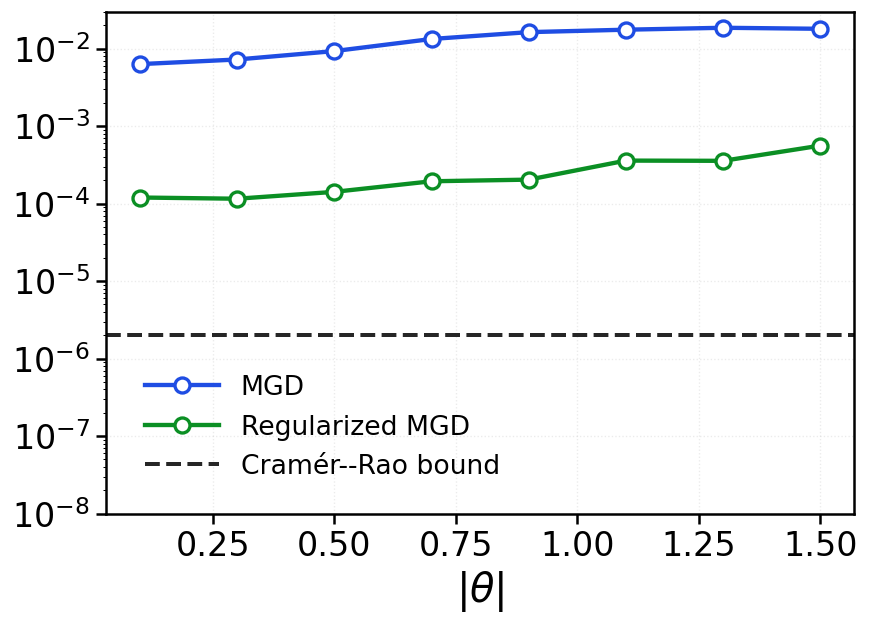

In [20]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Publication-style colors
blue = "#1f4de3"      # vivid blue
green = "#0b8f24"     # vivid green

# -------------------------------------------------------
# MGD
# -------------------------------------------------------
ax.plot(
    betas,
    kl_mgd_mean,
    "-o",
    color=blue,
    lw=2.6,
    ms=9,
    mfc="white",
    mec=blue,
    mew=2,
    label="MGD",
)

# -------------------------------------------------------
# Regularized MGD
# -------------------------------------------------------
ax.plot(
    betas,
    kl_reg_mean,
    "-o",
    color=green,
    lw=2.6,
    ms=9,
    mfc="white",
    mec=green,
    mew=2,
    label="Regularized MGD",
)

# -------------------------------------------------------
# Cramér-Rao bound
# -------------------------------------------------------
ax.axhline(
    cr_bound,
    color="0.15",
    linestyle="--",
    linewidth=2.4,
    label=r"Cramér--Rao bound",
)

# -------------------------------------------------------
# Axes
# -------------------------------------------------------
ax.set_yscale("log")
ax.set_xlabel(r"$|\theta|$")

ax.set_ylim(1e-8, 3e-2)

# -------------------------------------------------------
# Grid
# -------------------------------------------------------
ax.grid(
    which="major",
    linestyle=":",
    linewidth=0.8,
    alpha=0.25,
)

ax.set_axisbelow(True)

# -------------------------------------------------------
# Legend
# -------------------------------------------------------
ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.02, 0.02),
    frameon=False,
    handlelength=2.8,
)

plt.tight_layout()
plt.savefig("KL_bimodal_paper.png") 
plt.show() 

In [36]:
import pickle

with open("kl_summary.pkl", "rb") as f:
    summary = pickle.load(f)

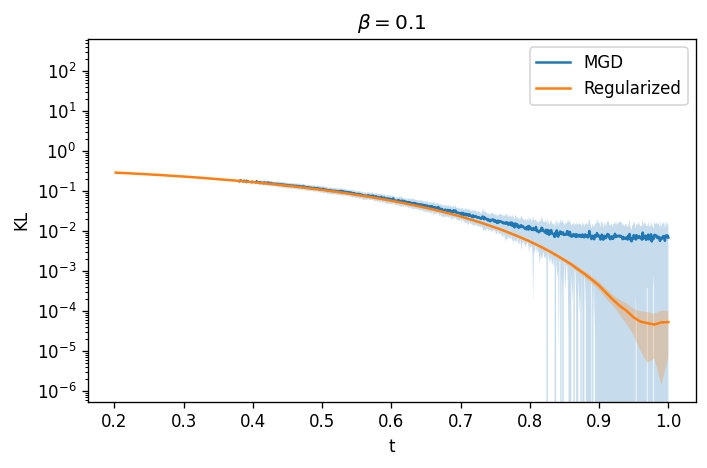

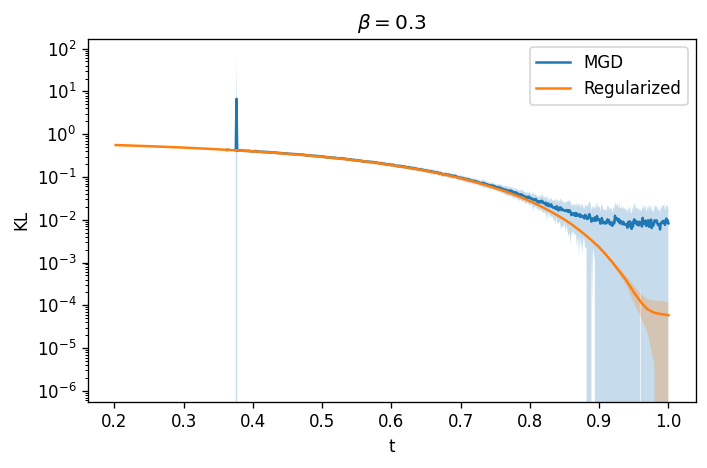

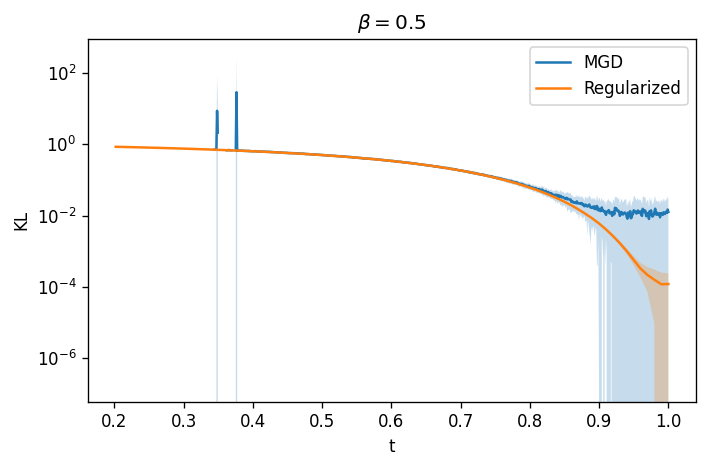

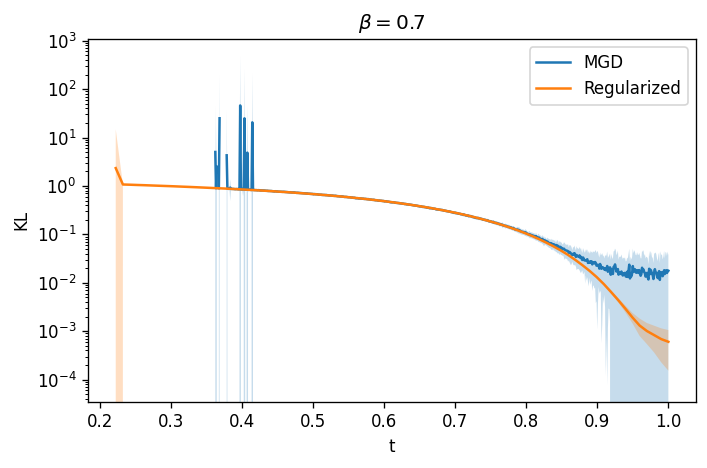

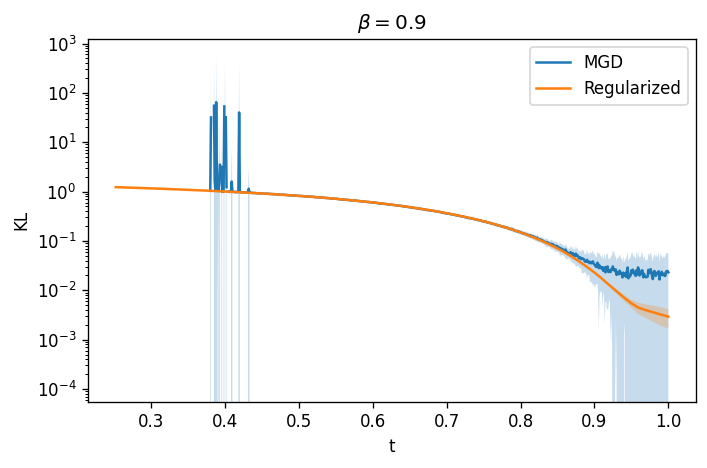

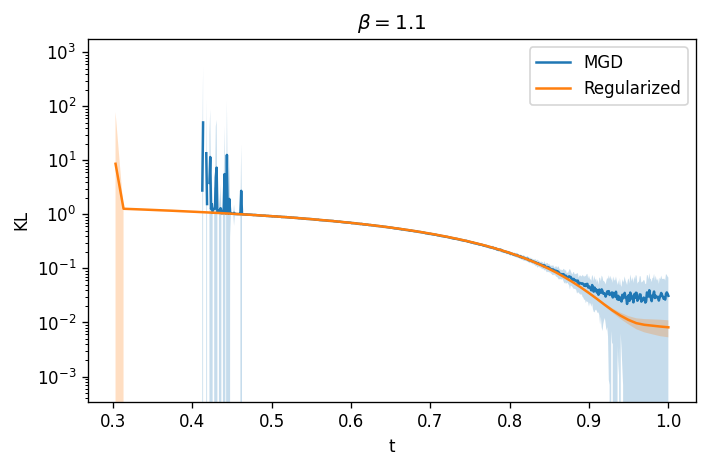

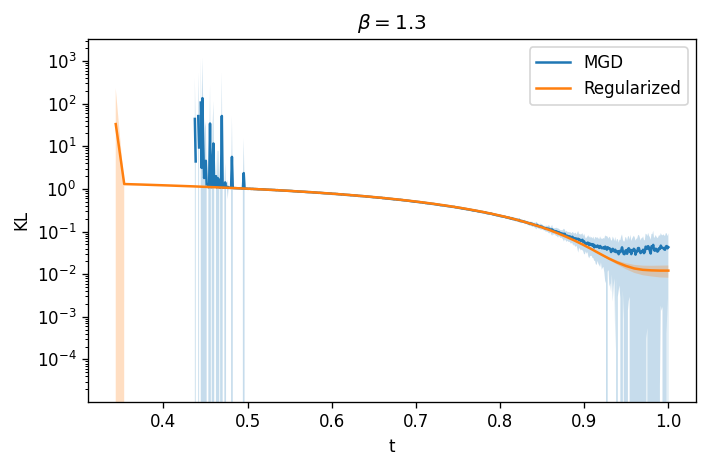

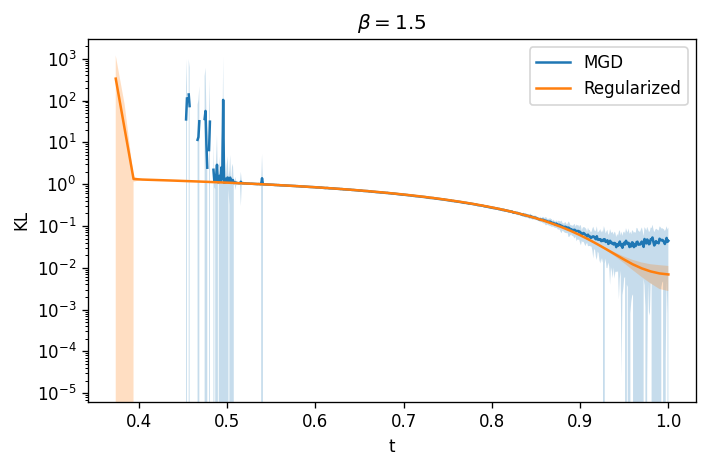

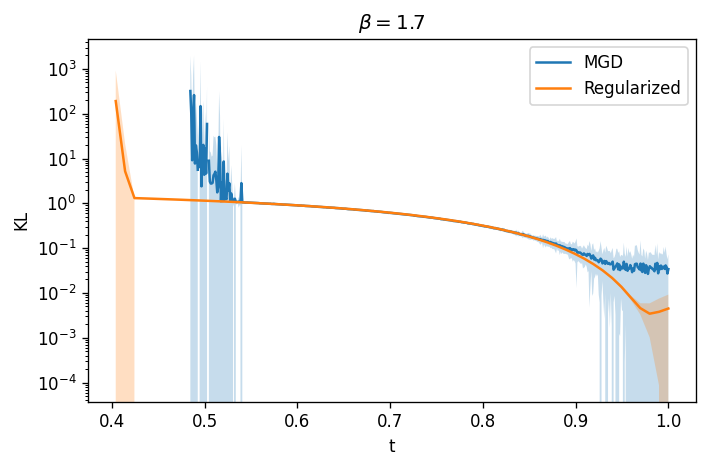

In [21]:
for r in summary:
    plt.figure(figsize=(6,4))
    for traj, label in [
        (r["traj_mgd"], "MGD"),
        (r["traj_reg"], "Regularized"),
    ]:
        t = np.linspace(0, 1, traj.shape[1])   # each trajectory gets its own time axis
        mean = traj.mean(axis=0)
        std = traj.std(axis=0)
        plt.plot(t, mean, label=label)
        plt.fill_between(t, mean-std, mean+std, alpha=.25)
 
    plt.yscale("log")
    plt.xlabel("t")
    plt.ylabel("KL")
    plt.title(rf"$\beta={r['beta']}$")
    plt.legend()
    plt.tight_layout()